In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, glob, json
from pathlib import Path
import numpy as np
import jax
from jax import value_and_grad, jit, vmap, grad, random
import jax.numpy as jnp
import flax.linen as nn
import jax.lax as lax
from flax import serialization
import matplotlib.pyplot as plt
import optax

from action_angle_networks.sk_models import MyActionAngleNetwork
from action_angle_networks.simulation import harmonic_motion_simulation as hsim
from functools import partial
from dataclasses import dataclass
from typing import Any, Callable, Sequence, Optional, List, Tuple, Dict

%config InlineBackend.figure_format = 'retina'


# Simulation 1d harmonic oscillator

\begin{equation}
H(q, p)=\sum_{i=1}^n \frac{p_i^2}{2 m_i}+\frac{k_{\text {wall }}}{2} \sum_{i=1}^n q_i^2+\frac{k_{\text {pair }}}{2} \sum_{1 \leq i < j \leq n} \left( q_i-q_j \right)^2 .
\end{equation}

Or, $H = T + V$, where $T$ is the motion energy and 
\begin{equation}
T = \frac{1}{2} p^\top M p,
\end{equation}
and
\begin{equation}
V=\frac{1}{2} q^\top\left(k_{\mathrm{wall}} I+k_{\mathrm{pair}}\left(n I-\mathbf{1 1}^{\top}\right)\right) q.
\end{equation}

# Rewite classes
To sample multiple initial values, we first rewirte the code into varialbe initial values.

First, let's sample $m$, $k_{\text{wall}}$ and $k_{\text{pair}}$.

In [3]:
# Example: quick sanity check
n = 1
T = 1000
dt = 0.01


In [4]:
seed = 42
rng = np.random.default_rng(seed)
m = rng.uniform(*(1.0, 3.0), size=(n,)).astype(np.float64)

k_wall = 1.0
k_pair = 0.5

In [5]:

@dataclass
class HarmonicParamsSInitVal:
    n: int
    m: np.ndarray         # (n,) masses per oscillator
    k_wall: float         # wall spring constant
    k_pair: float         # pairwise coupling spring constant
    # A_modes: np.ndarray   # (n,) amplitudes per normal mode
    # phi_modes: np.ndarray # (n,) phases per normal mode (radians)

def set_harmonic_params(
    n: int,
    m: Tuple[float, ...],
    k_wall: float = 0.01,
    k_pair: float = 0.005,    
) -> HarmonicParamsSInitVal:
    # Normal-mode amplitudes/phases
    # A_modes = rng.uniform(*A_range, size=(n,)).astype(np.float64)
    # phi_modes = rng.uniform(0.0, 2*np.pi, size=(n,)).astype(np.float64)
    return HarmonicParamsSInitVal(
        n=n, m=m, k_wall=float(k_wall), k_pair=float(k_pair),
        # A_modes=A_modes, phi_modes=phi_modes
    )

def harmonic_hamiltonian(q: np.ndarray, p: np.ndarray, params: HarmonicParamsSInitVal) -> float:
    """
    q, p: (B, n)
    """
    n = params.n
    V_wall = 0.5 * params.k_wall * np.sum(q**2, axis=1)  # (B,)
    V_pair = 0.5 * params.k_pair * ((np.sum(q, axis=1)**2 - np.sum(q**2, axis=1))/2.0)  # (B,)
    V = V_wall + V_pair # (B,)
    T = 0.5 * np.sum((p**2) / params.m, axis=1)  # (B,)
    H = T + V
    return float(H)


def harmonic_hamiltonian_jax(q: jnp.ndarray, p: jnp.ndarray, params: HarmonicParamsSInitVal) -> jnp.ndarray:
    """
    q, p: (B, n)  -> returns (B,)
    NOTE: m を jnp に変換して計算
    """
    if isinstance(params, dict):
        m = jnp.asarray(params["m"])
        k_wall = jnp.asarray(params["k_wall"])
        k_pair = jnp.asarray(params["k_pair"])
    else:
        m = jnp.asarray(params.m)
        k_wall = jnp.asarray(params.k_wall)
        k_pair = jnp.asarray(params.k_pair)
    V_wall = 0.5 * k_wall * jnp.sum(q**2, axis=1)  # (B,)
    V_pair = 0.5 * k_pair * (
        (jnp.sum(q, axis=1) ** 2 - jnp.sum(q**2, axis=1)) / 2.0
    )
    T = 0.5 * jnp.sum((p**2) / m, axis=1)  # (B,)
    return T + V_wall + V_pair  # (B,)

def equation_of_motion(q: jnp.ndarray, p: jnp.ndarray, params: HarmonicParamsSInitVal) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """
    Returns the time derivatives of the positions and momenta.
    """
    dqdt = p / params.m[None, :]  # (B, n)
    I = np.eye(n)
    J = np.ones((n, n))
    L = -(params.k_wall + n * params.k_pair) * I + params.k_pair * J
    dpdt = jnp.matmul(q, jnp.asarray(L).T)  # (B, n)
    #dpdt = -jnp.gradient(harmonic_hamiltonian_jax(q, p, params), axis=1)  # (B, n)
    return dqdt, dpdt

def _normal_mode_eigendecomposition(params: HarmonicParamsSInitVal):
    """
    Returns eigenvalues/eigenvectors for q¨ = M^{-1} L q.
    Repoに合わせて L = -(k_wall + n*k_pair) I + k_pair 1 1^T を用い、
    固有値は負になる（w = sqrt(-eigvals)）。
    """
    n = params.n
    I = jnp.eye(n)
    J = jnp.ones((n, n))
    L = -(params.k_wall + n * params.k_pair) * I + params.k_pair * J
    M_sqrt_inv = jnp.diag(1.0 / jnp.sqrt(params.m))

    # 対称化
    S = M_sqrt_inv @ L @ M_sqrt_inv
    eigvals, U = jnp.linalg.eigh(S)              # 決定的になりやすい
    V = M_sqrt_inv @ U                          # 元の一般化固有ベクトルへ
    return eigvals.real, V.real                 # (n,), (n,n)

    # M_inv = np.diag(1.0 / params.m)
    # M_inv_L = M_inv @ L
    # eigvals, eigvecs = np.linalg.eig(M_inv_L)
    # eigvals = eigvals.real
    # eigvecs = eigvecs.real
    # return eigvals, eigvecs  # (n,), (n,n)

def initial_modes_from_qp(q0, p0, m, V, w, eps=1e-12):
    """
    q0, p0: (n,)
    m: (n,), V: (n,n) with columns = mode vectors (your aux["eigvecs"])
    w: (n,) angular frequencies
    returns: A_modes (n,), phi_modes (n,)
    """
    M = jnp.diag(jnp.asarray(m))
    q0 = jnp.asarray(q0); p0 = jnp.asarray(p0)
    V = jnp.asarray(V);   w  = jnp.asarray(w)

    q_mode0   = V.T @ (M @ q0)        # shape (n,)
    qdot_mode0= V.T @ p0              # since p = M qdot

    # handle near-zero frequencies safely
    w_safe = jnp.where(w < eps, eps, w)

    A = jnp.sqrt(q_mode0**2 + (qdot_mode0 / w_safe)**2)
    phi = jnp.arctan2(-qdot_mode0 / w_safe, q_mode0)

    # (optional) if you truly have zero-frequency modes (e.g., k_wall=0),
    # their motion is linear in time and (A, phi) is not well-defined.
    # You can mark them, or set (A, phi) via a convention:
    zero_mask = (w < eps)
    # e.g., keep A = |q_mode0|, phi = 0 for zeros (or any consistent choice)
    A = jnp.where(zero_mask, jnp.abs(q_mode0), A)
    phi = jnp.where(zero_mask, 0.0, phi)

    return A, phi


def simulate_coupled_1d_harmonic_init_values(
    params: HarmonicParamsSInitVal,
    num_steps: int,
    dt: float,
    q0: jnp.ndarray,
    p0: jnp.ndarray
) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray, Dict]:
    """
    Returns:
      t: (T,)
      q: (T, n) positions
      p: (T, n) momenta  (p = m * dq/dt)
      aux: dict with eigvals/eigvecs/w
    """
    n = params.n
    t = jnp.arange(num_steps, dtype=jnp.float64) * float(dt)

    # Normal modes
    eigvals, V = _normal_mode_eigendecomposition(params)
    w = jnp.sqrt(jnp.clip(-eigvals, a_min=0.0, a_max=None))  # angular freq

    # compute A_modes, phi_modes from (q0, p0)
    M = jnp.diag(jnp.asarray(m))
    q_mode0   = V.T @ (M @ q0)        # shape (n,)
    qdot_mode0= V.T @ p0              # since p = M qdot

    # # handle near-zero frequencies safely
    # w_safe = jnp.where(w < eps, eps, w)

    A = jnp.sqrt(q_mode0**2 + (qdot_mode0 / w)**2)
    phi = jnp.arctan2(-qdot_mode0 / w, q_mode0)

    # Mode-space trajectories
    Wt_phi = t[:, None] * w[None, :] + phi[None, :]  # (T, n)
    q_mode = A[None, :] * jnp.cos(Wt_phi)              # (T, n)
    qdot_mode = -A[None, :] * (w[None, :]) * jnp.sin(Wt_phi)  # (T, n)

    # Map back to physical coords: q = V q_mode, qdot = V qdot_mode
    q = q_mode @ V.T
    qdot = qdot_mode @ V.T
    p = qdot * params.m[None, :]  # momentum = m * qdot

    aux = {"eigvals": eigvals, "eigvecs": V, "w": w}
    return t, q, p, aux

def flow_coupled_1d_harmonic_init_values(
    params: HarmonicParamsSInitVal,
    num_steps: tuple[int, ...],
    dt: float,
    q0: jnp.ndarray,
    p0: jnp.ndarray
) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray, Dict]:
    """
    Returns:
      t: tuple with B integers, times for each batch
      q0: (B, n) positions for each batch
      p0: (B, n) momenta  (p = m * dq/dt) for each batch
      aux: dict with eigvals/eigvecs/w
    """
    n = params.n
    # t = jnp.arange(num_steps, dtype=jnp.float64) * float(dt)
    t = jnp.array([ns * float(dt) for ns in num_steps], dtype=jnp.float64) # shape (B,)

    # Normal modes
    eigvals, V = _normal_mode_eigendecomposition(params)
    w = jnp.sqrt(jnp.clip(-eigvals, a_min=0.0, a_max=None))  # (n,) angular freq

    # compute A_modes, phi_modes from (q0, p0)
    M = jnp.diag(jnp.asarray(params.m)) # (n,n)
    # M_inv = jnp.diag(jnp.asarray(1. / params.m)) # (n,n)
    q_mode0   = (q0 @ M) @ V    # elementwis
    qdot_mode0= p0 @ V              # since p = M qdot

    # q_mode0   = V.T @ (M @ q0)        # shape (n,)
    # qdot_mode0= V.T @ p0              # since p = M qdot

    # # handle near-zero frequencies safely
    # w_safe = jnp.where(w < eps, eps, w)

    A = jnp.sqrt(q_mode0**2 + (qdot_mode0 / w)**2) # (B,n)
    phi = jnp.arctan2(-qdot_mode0 / w, q_mode0)    # (B,n)

    # Mode-space trajectories
    wt_phi = t[:, None] * w[None, :] + phi    # (B, n)
    q_mode = A * jnp.cos(wt_phi)              # (B, n)
    qdot_mode = -A * (w[None, :]) * jnp.sin(wt_phi)  # (B, n)

    # Map back to physical coords: q = V q_mode, qdot = V qdot_mode
    q = q_mode @ V.T
    qdot = qdot_mode @ V.T
    p = qdot * params.m[None, :]  # momentum = m * qdot

    aux = {"eigvals": eigvals, "eigvecs": V, "w": w}
    return t, q, p, aux


In [6]:

B = 3000
Ts = tuple(np.arange(0, B).tolist())
#Ts = tuple(np.random.randint(500, 1500, size=(B,)).tolist())
t, q, p, aux = flow_coupled_1d_harmonic_init_values(
    params=set_harmonic_params(n=n, m=m, k_wall=k_wall, k_pair=k_pair),
    num_steps=Ts,
    dt=0.01,
    q0=jax.random.normal(jax.random.PRNGKey(0), (1,n)),
    p0=jax.random.normal(jax.random.PRNGKey(0), (1,n)),
)



/tmp/1025040.1229/ipykernel_282971/915626916.py:186: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  t = jnp.array([ns * float(dt) for ns in num_steps], dtype=jnp.float64) # shape (B,)


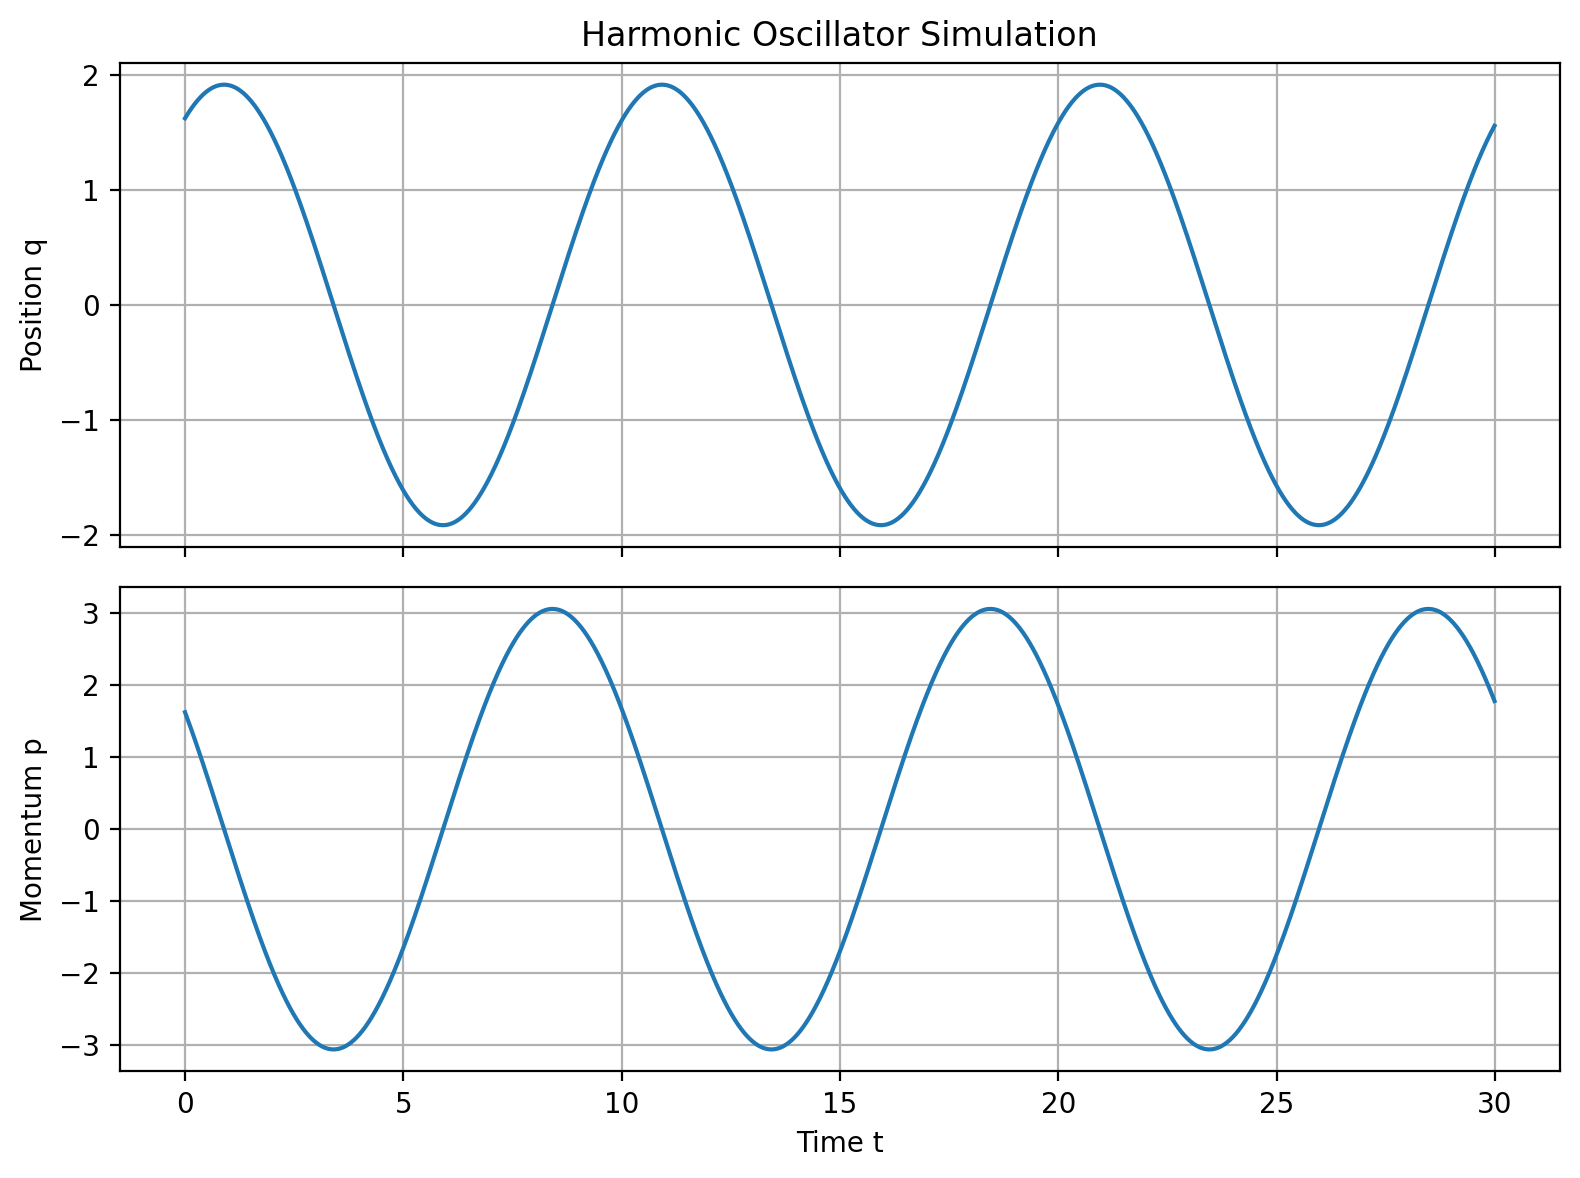

In [7]:
# plot q and p
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax[0].plot(t, q)
ax[0].set_ylabel('Position q')
ax[0].set_title('Harmonic Oscillator Simulation')
ax[0].grid()
ax[1].plot(t, p)
ax[1].set_ylabel('Momentum p')
ax[1].set_xlabel('Time t')
ax[1].grid()
plt.tight_layout()
plt.show()

# Prepare the dataset
Here we settle up the dataset for training. Let $x=(q, p) \in X,\; \dot{x} = (\dot{q}, \dot{p})$, and the flow $\varphi_t: X \to X$ follow $\dot{x} = J\nabla_xH$. We define the dataset $\mathcal{D}$ as
\begin{equation}
\mathcal{D} = \{(x_0, \dot{x}_0, x(t), t) \mid x_0 \in X,\; \dot{x}_0 = J\nabla H(x_0),\; x(t) = \varphi_t(x),\; t\in\mathbb{R}_{>0}\}.
\end{equation}

To create such a dataset (technically, a finite subset of the dataset define above), we sample 
+ $x_0$ from a compact set
+ $t$ with an upper bount $t_{\text{max}}$


In [8]:
#hyper_params = set_harmonic_params(n=n, m=m, k_wall=k_wall, k_pair=k_pair)
hyper_params = set_harmonic_params(n=n, m=m[:n], k_wall=k_wall, k_pair=k_pair)


In [9]:
def create_dataset(x0, steps, dt=dt, hyper_params=hyper_params):
    """
    x0: (B, 2n) initial conditions
    steps: (B,) time steps for each batch
    Returns:
    x0: (B, 2n)
    x0_dot: (B, 2n)
    xt: (B, 2n)
    t: (B,)
    """
    B, dim = x0.shape
    n = dim // 2
    q0 = x0[:, :n]
    p0 = x0[:, n:]

    t, q, p, _ = flow_coupled_1d_harmonic_init_values(
        params=set_harmonic_params(n=n, m=hyper_params.m, k_wall=hyper_params.k_wall, k_pair=hyper_params.k_pair),
        num_steps=tuple(steps.tolist()),
        dt=dt,
        q0=q0,
        p0=p0
    )
    xt = jnp.concatenate([q, p], axis=1)  # (B, 2n)

    # compute x0_dot
    dqdt0 = p0 / hyper_params.m[None, :]  # (B, n)
    I = np.eye(n)
    J = np.ones((n, n))
    L = -(hyper_params.k_wall + n * hyper_params.k_pair) * I + hyper_params.k_pair * J
    dpdt0 = jnp.matmul(q0, jnp.asarray(L).T)  # (B, n)
    x0_dot = jnp.concatenate([dqdt0, dpdt0], axis=1)  # (B, 2n)

    return x0, x0_dot, xt, t
    

In [10]:
N_train = 500000
N_test  = 125000
delta_t_max = 50.0
train_t_dist = "uniform" # "uniform", "step_scheduling", "LNP"

# Below ignored unless "LNP"
delta_t_mean = 0.1
sigma2 = 0.2

key = jax.random.PRNGKey(0)
q_train_key, p_train_key, dt_train_key, key = jax.random.split(key, 4)
q0_train = jax.random.uniform(q_train_key, shape=(N_train, n), minval=-3.0, maxval=3.0)
p0_train = jax.random.uniform(p_train_key, shape=(N_train, n), minval=-3.0, maxval=3.0)

if train_t_dist == "uniform":
    delta_t_train = jnp.clip(
        dt * jax.random.randint(dt_train_key, shape=(N_train,), minval=1, maxval=delta_t_max),
        min=dt,
        max=delta_t_max
    )
elif train_t_dist == "step_scheduling":
    unif_vec = jax.random.uniform(dt_train_key, shape=(N_train,), minval=0.0, maxval=1.0)
    delta_t_train = jnp.clip(
        dt * jnp.ceil( unif_vec * ((delta_t_max * jnp.arange(N_train)/N_train)//dt)),
        min=dt,
        max=delta_t_max
    )
elif train_t_dist == "LNP":
    sigma2 =  1.0 / 2.0
    dt_train_key, dt_train_key2 = jax.random.split(dt_train_key, 2)
    tau = jnp.sqrt(sigma2) * jax.random.normal( key=dt_train_key, shape=(N_train,) ) + jnp.log( float(delta_t_mean//dt-1) ) - 0.5 * sigma2
    # tau ~ N(log(T_mean-1)-0.5*sigma^2, sigma)
    delta_t_train = dt* (jax.random.poisson(key=dt_train_key2, lam=jnp.exp(tau)) + 1)

q_test_key, p_test_key, dt_test_key = jax.random.split(key, 3)
q0_test = jax.random.uniform(q_test_key, shape=(N_test, n), minval=-3.0, maxval=3.0)
p0_test = jax.random.uniform(p_test_key, shape=(N_test, n), minval=-3.0, maxval=3.0)
delta_t_test = jax.random.uniform(dt_test_key, shape=(N_test,), minval=0.01, maxval=30.0)

step_counts_train = jnp.maximum(1, jnp.round(delta_t_train / dt).astype(int))
step_counts_test = jnp.maximum(1, jnp.round(delta_t_test / dt).astype(int))

train_dataset = create_dataset(
    x0=jnp.concatenate([q0_train, p0_train], axis=1),
    steps=step_counts_train,
    dt=dt,
    hyper_params=hyper_params
)
test_dataset = create_dataset(
    x0=jnp.concatenate([q0_test, p0_test], axis=1),
    steps=step_counts_test,
    dt=dt,
    hyper_params=hyper_params
)

/tmp/1025040.1229/ipykernel_282971/915626916.py:186: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  t = jnp.array([ns * float(dt) for ns in num_steps], dtype=jnp.float64) # shape (B,)


In [11]:
step_counts_train

Array([34, 17, 34, ..., 27, 42, 20], dtype=int32)

In [12]:
print(train_dataset[0])
print(train_dataset[2])

[[ 2.0538845 -2.956237 ]
 [-1.9057281 -2.8746529]
 [-1.6369314  0.488559 ]
 ...
 [-2.1526237 -2.3156075]
 [ 0.9380472 -1.0076087]
 [-2.522541  -2.1130722]]
[[ 1.6159556  -3.58248   ]
 [-2.0863688  -2.5350027 ]
 [-1.5352348   1.029875  ]
 ...
 [-2.3661165  -1.704118  ]
 [ 0.74157697 -1.3623791 ]
 [-2.6681993  -1.5933185 ]]


# Build model & train

In [13]:
model = MyActionAngleNetwork(
    dim_config=n,
    dim_hidden=256,
    #dim_hidden_list=[64, 256, 64],
    num_gsblocks=30,
    type_polar="canonical",
    activation=nn.silu,
    mlp_res_connection=False,
    theta_predictor="gradient",
    learn_scale=True
)


In [14]:
rng = jax.random.PRNGKey(0)
q0 = jnp.zeros((1, int(n)))
p0 = jnp.zeros((1, int(n)))
delta_t0 = jnp.asarray(0.1)

variables = model.init(rng, q0, p0, delta_t0)
params = variables['params']
num_params = sum(jax.tree_util.tree_leaves(jax.tree_util.tree_map(lambda x: x.size, params)))
print(f'Total parameters: {num_params}')


Total parameters: 89633


# Training

In [15]:
# --- New helper: batched ∂H/∂q, ∂H/∂p ---
# def H_gt_grad_batch(q: jnp.ndarray, p: jnp.ndarray, gt_params):
#     """
#     q, p: (B, n) -> dHdq, dHdp each (B, n)
#     """
#     def Hsum(q, p):
#         return harmonic_hamiltonian_jax(q, p, gt_params).sum()

#     dHdq, dHdp = jax.grad(Hsum, argnums=(0, 1))(q, p)
#     return dHdq, dHdp


def train_step(params,
               opt_state,
               dtst_batch,
               apply_fn,
               tx,
               loss_weights=(1.0, 1.0, 0.0, 0.1),
               action_loss_type='var'):
    x, x_dot, y, delta_t = dtst_batch  # x, x_dot, y: (B, 2n), delta_t: (B,)    
    
    n = x.shape[1] // 2
    q, p = x[:, :n], x[:, n:]  # (B, n), (B, n)
    q_dot, p_dot = x_dot[:, :n], x_dot[:, n:]

    # dHdq_gt, dHdp_gt = H_gt_grad_batch(q, p, gt_params)

    # def H_hat_single(pp, qi, pi):
    #     return apply_fn({'params': pp}, qi[None, :], pi[None, :],
    #                     method=model.hamiltonian).squeeze()

    # grad_q_H_hat_single = jax.grad(H_hat_single, argnums=1)
    # grad_p_H_hat_single = jax.grad(H_hat_single, argnums=2)
    # dHdq_model = jax.vmap(lambda qi, pi: grad_q_H_hat_single(params, qi, pi))(q, p)
    # dHdp_model = jax.vmap(lambda qi, pi: grad_p_H_hat_single(params, qi, pi))(q, p)

    def loss_fn(pp):
        q_, p_, I, _ = apply_fn({'params': pp}, q, p, delta_t, train=True)

        loss_q_se = ((q_ - y[:, :n]) ** 2).mean()
        loss_p_se = ((p_ - y[:, n:]) ** 2).mean()

        def H_hat_single(qi, pi):
            return apply_fn({'params': pp}, qi[None, :], pi[None, :],
                            method=model.hamiltonian).squeeze()

        dHdq_model = jax.vmap(lambda qi, pi: jax.grad(H_hat_single, argnums=0)(qi, pi))(q, p)
        dHdp_model = jax.vmap(lambda qi, pi: jax.grad(H_hat_single, argnums=1)(qi, pi))(q, p)

        L_HNN = ((dHdq_model + p_dot) ** 2).mean() + ((dHdp_model - q_dot) ** 2).mean()

        if action_loss_type=='var':
            L_action = lax.cond(
                loss_weights[2] > 0.0,
                lambda I: jnp.var(I, axis=0).sum(),
                lambda I: 0.0,
                I
            )
        elif action_loss_type=='quadratic_variation':
            L_action = jnp.sum(jnp.square(I[1:, :] - I[:-1, :])) / I.shape[0]


        return (loss_weights[0] * loss_q_se +
                loss_weights[1] * loss_p_se +
                loss_weights[2] * L_action +
                loss_weights[3] * L_HNN)
        #return loss_q_se + loss_p_se + alpha * L_action + beta * L_HNN

    loss, grads = value_and_grad(loss_fn)(params)
    updates, opt_state = tx.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss


train_step_jit = jax.jit(train_step, static_argnames=('apply_fn', 'tx'))


In [16]:
@partial(jax.jit, static_argnames=('apply_fn',))
def eval_batch(params, x, y, delta_t, *, apply_fn):
    n = x.shape[1] // 2
    q, p = x[:, :n], x[:, n:]

    q_, p_, _, _ = apply_fn({'params': params}, q, p, delta_t, train=False)

    loss_q_mse = ((q_ - y[:, :n]) ** 2).mean()
    loss_p_mse = ((p_ - y[:, n:]) ** 2).mean()

    return loss_q_mse + loss_p_mse


In [17]:
# --- Replace: 学習ループの該当部分 ---
seed = 201
lr = 1e-3
batch_size = 256
epoch = 1
ep_shuffle_chunks = 4

log_every = 50
loss_weights = (1.0, 1.0, 0.0, 0.0)
delta_t = dt  # base time step
delta_t_max = 0.5  # max jump multiplier during training


key = jax.random.PRNGKey(seed)
variables = model.init(key, jnp.zeros((1, n)), jnp.zeros((1, n)), jnp.asarray(dt))
nn_params = variables['params']

tx = optax.adam(learning_rate=lr)
opt_state = tx.init(nn_params)

idx_serial_batch = 0
batch_losses = []

for ep in range(epoch):
    
    if ep == 0:
        x0_train, x0_dot_train, xt_train, t_train = train_dataset
    else:
        # Shuffle training data
        # なんとなくtを最初の方は短く→あとで長くとトレーニングしたいので、何チャンクかにわけてそのチャンク内でシャッフル
        # epoch=1なら関係ない
        for idx_ep in range(ep_shuffle_chunks):
            perm_key, key = jax.random.split(key)
            perm = jax.random.permutation(perm_key, N_train // ep_shuffle_chunks)
            start_idx = idx_ep * (N_train // ep_shuffle_chunks)
            end_idx = (idx_ep + 1) * (N_train // ep_shuffle_chunks)
            x0_train, x0_dot_train, xt_train, t_train = train_dataset
            x0_train = x0_train.at[start_idx:end_idx].set(x0_train[start_idx:end_idx][perm])
            x0_dot_train = x0_dot_train.at[start_idx:end_idx].set(x0_dot_train[start_idx:end_idx][perm])
            xt_train = xt_train.at[start_idx:end_idx].set(xt_train[start_idx:end_idx][perm])
            t_train = t_train.at[start_idx:end_idx].set(t_train[start_idx:end_idx][perm])
    
    # Mini-batch training
    num_batches = N_train // batch_size
    epoch_loss = 0.0

    for i in range(num_batches):
        batch_x0     = x0_train[i*batch_size:(i+1)*batch_size]
        batch_x0_dot = x0_dot_train[i*batch_size:(i+1)*batch_size]
        batch_xt     = xt_train[i*batch_size:(i+1)*batch_size]
        batch_t      = t_train[i*batch_size:(i+1)*batch_size]

        nn_params, opt_state, batch_loss = train_step_jit(
            nn_params, opt_state,
            (batch_x0, batch_x0_dot, batch_xt, batch_t),
            apply_fn=model.apply, tx=tx,
            loss_weights=loss_weights
        )
        total_batch_loss = batch_loss * len(batch_t)
        epoch_loss += total_batch_loss
        #epoch_loss += batch_loss *         
        batch_losses.append(batch_loss)

        if (idx_serial_batch + 1) % log_every == 0:
            print(f"Epoch {ep+1}, Batch {i+1}/{num_batches}, Loss: {batch_loss:.6f}")

        if (idx_serial_batch + 1) % log_every == 0 or idx_serial_batch == 1 or (ep==epoch-1 and i==num_batches-1):
            test_losses = []
            num_test_batches = N_test // batch_size
            for j in range(num_test_batches):
                batch_x0_test = test_dataset[0][j*batch_size:(j+1)*batch_size]
                batch_x0_dot_test = test_dataset[1][j*batch_size:(j+1)*batch_size]
                batch_xt_test = test_dataset[2][j*batch_size:(j+1)*batch_size]
                batch_t_test = test_dataset[3][j*batch_size:(j+1)*batch_size]

                test_loss = eval_batch(
                    nn_params,
                    batch_x0_test,
                    batch_xt_test,
                    batch_t_test,
                    apply_fn=model.apply
                )
                test_losses.append(test_loss * len(batch_t_test))
            total_test_loss = sum(test_losses) / N_test
            print(f"*** Test Loss after {idx_serial_batch} batches: {total_test_loss:.6f} ***")
        
        idx_serial_batch += 1

    epoch_loss /= N_train
    print(f"Epoch {ep+1} completed. Average Loss: {epoch_loss:.6f}")

    


*** Test Loss after 1 batches: 1528763252736.000000 ***
Epoch 1, Batch 50/1953, Loss: 62695392.000000
*** Test Loss after 49 batches: 1821111808.000000 ***
Epoch 1, Batch 100/1953, Loss: 255482.421875
*** Test Loss after 99 batches: 790127616.000000 ***
Epoch 1, Batch 150/1953, Loss: 1766.107300
*** Test Loss after 149 batches: 6587514.500000 ***
Epoch 1, Batch 200/1953, Loss: 0.528427
*** Test Loss after 199 batches: 793.074219 ***
Epoch 1, Batch 250/1953, Loss: 0.281956
*** Test Loss after 249 batches: 430.424438 ***
Epoch 1, Batch 300/1953, Loss: 0.271225
*** Test Loss after 299 batches: 353.146851 ***
Epoch 1, Batch 350/1953, Loss: 14.629459
*** Test Loss after 349 batches: 351.218872 ***
Epoch 1, Batch 400/1953, Loss: 0.236429
*** Test Loss after 399 batches: 58884.964844 ***
Epoch 1, Batch 450/1953, Loss: 0.290974
*** Test Loss after 449 batches: 235.891373 ***
Epoch 1, Batch 500/1953, Loss: 15.379597
*** Test Loss after 499 batches: 209.074875 ***
Epoch 1, Batch 550/1953, Loss: 

In [18]:
i = 24
batch_x0     = x0_train[i*batch_size:(i+1)*batch_size]
batch_x0_dot = x0_dot_train[i*batch_size:(i+1)*batch_size]
batch_xt     = xt_train[i*batch_size:(i+1)*batch_size]
batch_t      = t_train[i*batch_size:(i+1)*batch_size]


In [19]:
print(i*batch_size, (i+1)*batch_size)

6144 6400


In [20]:

t_flow, q_flow, p_flow, _ = flow_coupled_1d_harmonic_init_values(
    params=hyper_params,
    num_steps=tuple((batch_t//dt).astype(int)),
    dt=dt, q0=batch_x0[:, :n], p0=batch_x0[:, n:])

x0, x0_dot, xt, t_dataset = create_dataset(
    x0=batch_x0,
    steps=(batch_t//dt).astype(int), dt=dt, hyper_params=hyper_params)

print(jnp.allclose(t_flow, t_dataset))
print(jnp.allclose(q_flow, xt[:, :1]))
print(jnp.allclose(p_flow, xt[:, 1:]))


/tmp/1025040.1229/ipykernel_282971/915626916.py:186: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  t = jnp.array([ns * float(dt) for ns in num_steps], dtype=jnp.float64) # shape (B,)


True
True
True


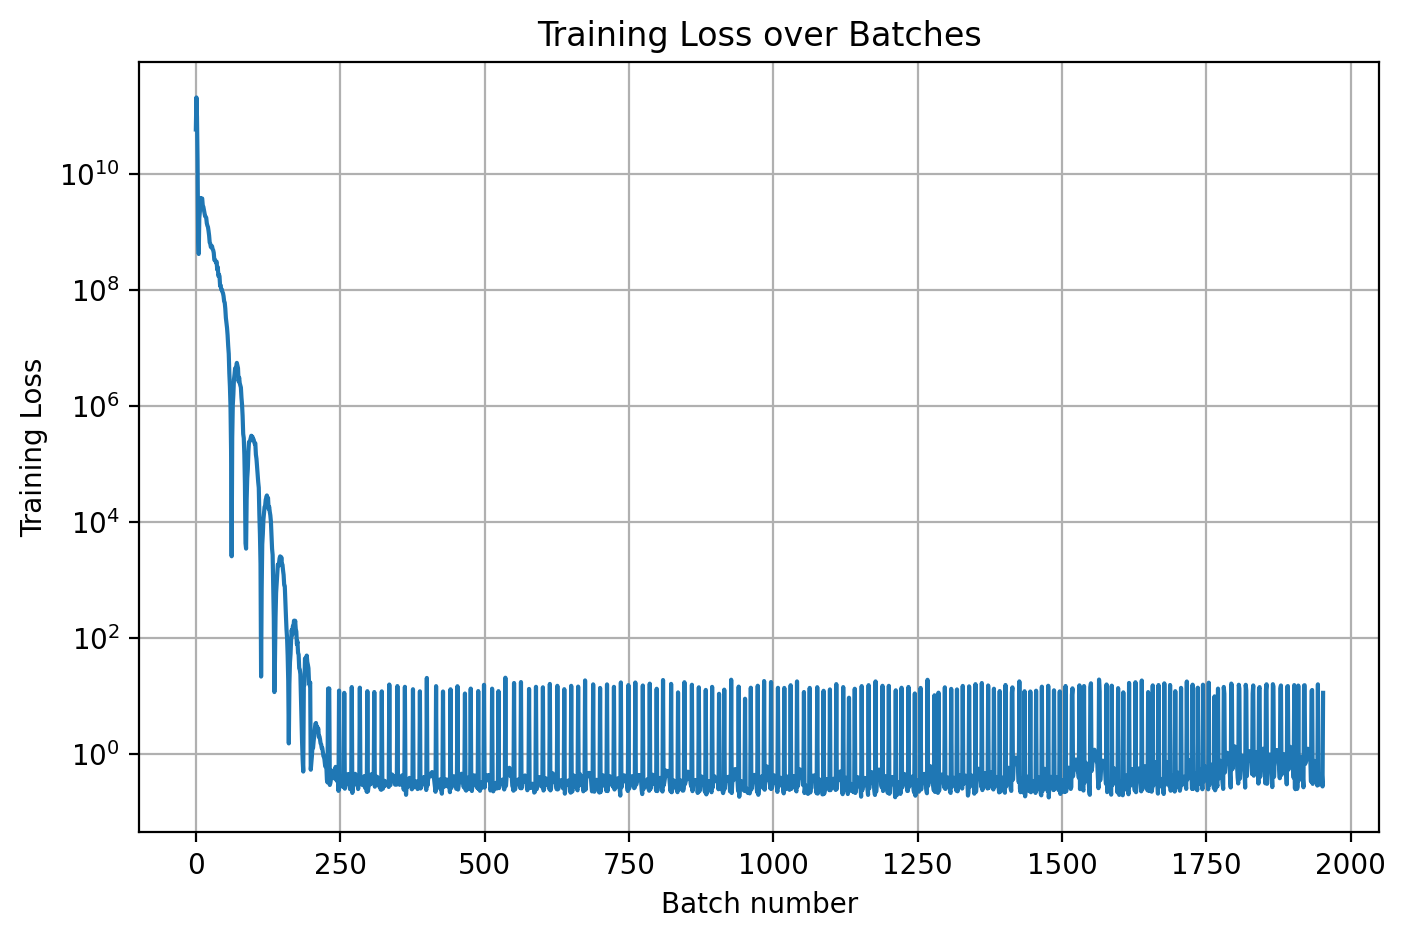

In [21]:
ax, fig = plt.subplots(figsize=(8, 5))
fig.plot(batch_losses)
fig.set_yscale('log')
fig.set_xlabel('Batch number')
fig.set_ylabel('Training Loss')
fig.set_title('Training Loss over Batches')
fig.grid()
plt.show()

In [22]:
train_dataset[0].shape

(500000, 2)

In [23]:
print(train_dataset[3])

[0.34 0.17 0.34 ... 0.27 0.42 0.2 ]


(array([10093., 10452., 10052., 10148., 10059., 10224., 10171., 10310.,
        10377., 10296., 10178., 10212., 10234., 10116., 10290., 10221.,
        10127., 10213., 10217.,  9963., 10182., 10110., 10346., 10324.,
            0., 10087., 10291., 10339., 10250., 10209., 10324., 10306.,
        10136., 10138., 10280., 10290., 10128., 10192., 10123., 10041.,
        10124., 10187., 10270., 10108., 10245., 10239., 10170., 10192.,
        10247., 10169.]),
 array([0.01      , 0.0196    , 0.0292    , 0.0388    , 0.0484    ,
        0.058     , 0.0676    , 0.0772    , 0.0868    , 0.0964    ,
        0.106     , 0.1156    , 0.1252    , 0.1348    , 0.1444    ,
        0.154     , 0.1636    , 0.1732    , 0.18280001, 0.19240001,
        0.20200001, 0.21160001, 0.2212    , 0.2308    , 0.2404    ,
        0.25      , 0.25960001, 0.2692    , 0.27880001, 0.28839999,
        0.29800001, 0.30759999, 0.31720001, 0.32680002, 0.3364    ,
        0.34600002, 0.3556    , 0.36520001, 0.3748    , 0.38440001

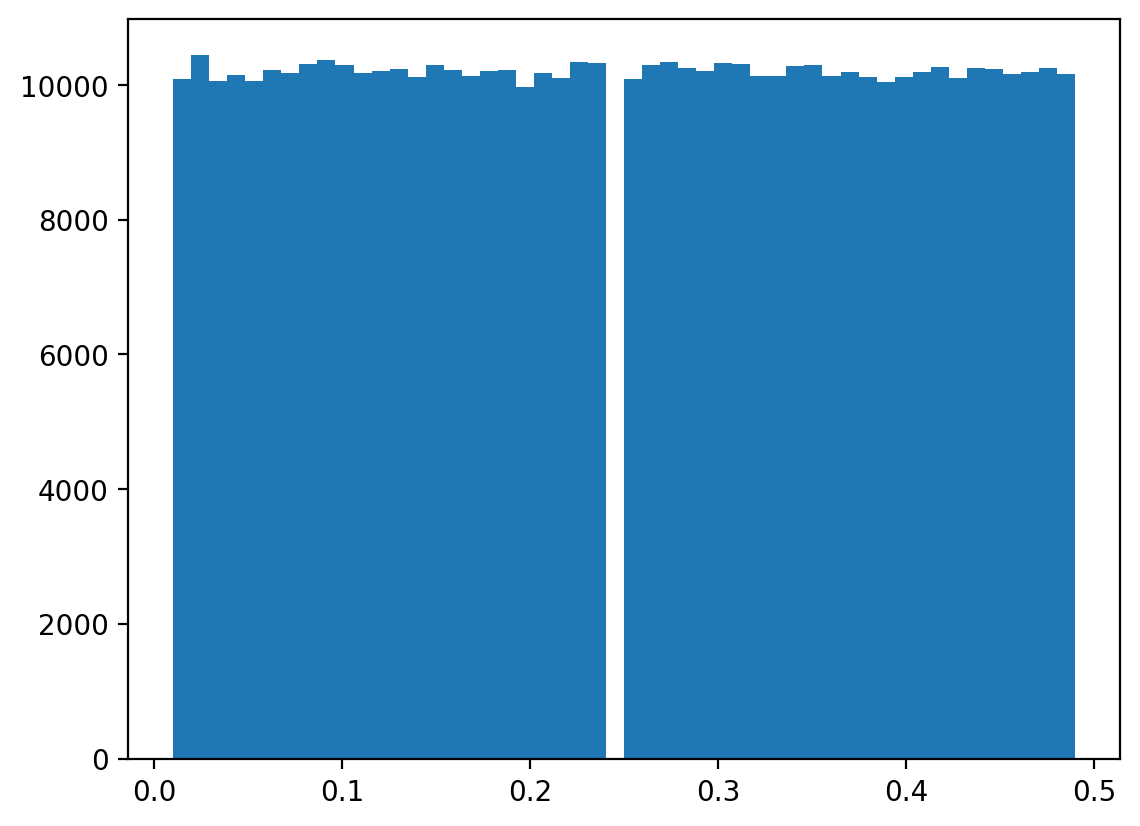

In [24]:
plt.hist(train_dataset[3], bins=50)

[0.18]


/tmp/1025040.1229/ipykernel_282971/915626916.py:186: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  t = jnp.array([ns * float(dt) for ns in num_steps], dtype=jnp.float64) # shape (B,)


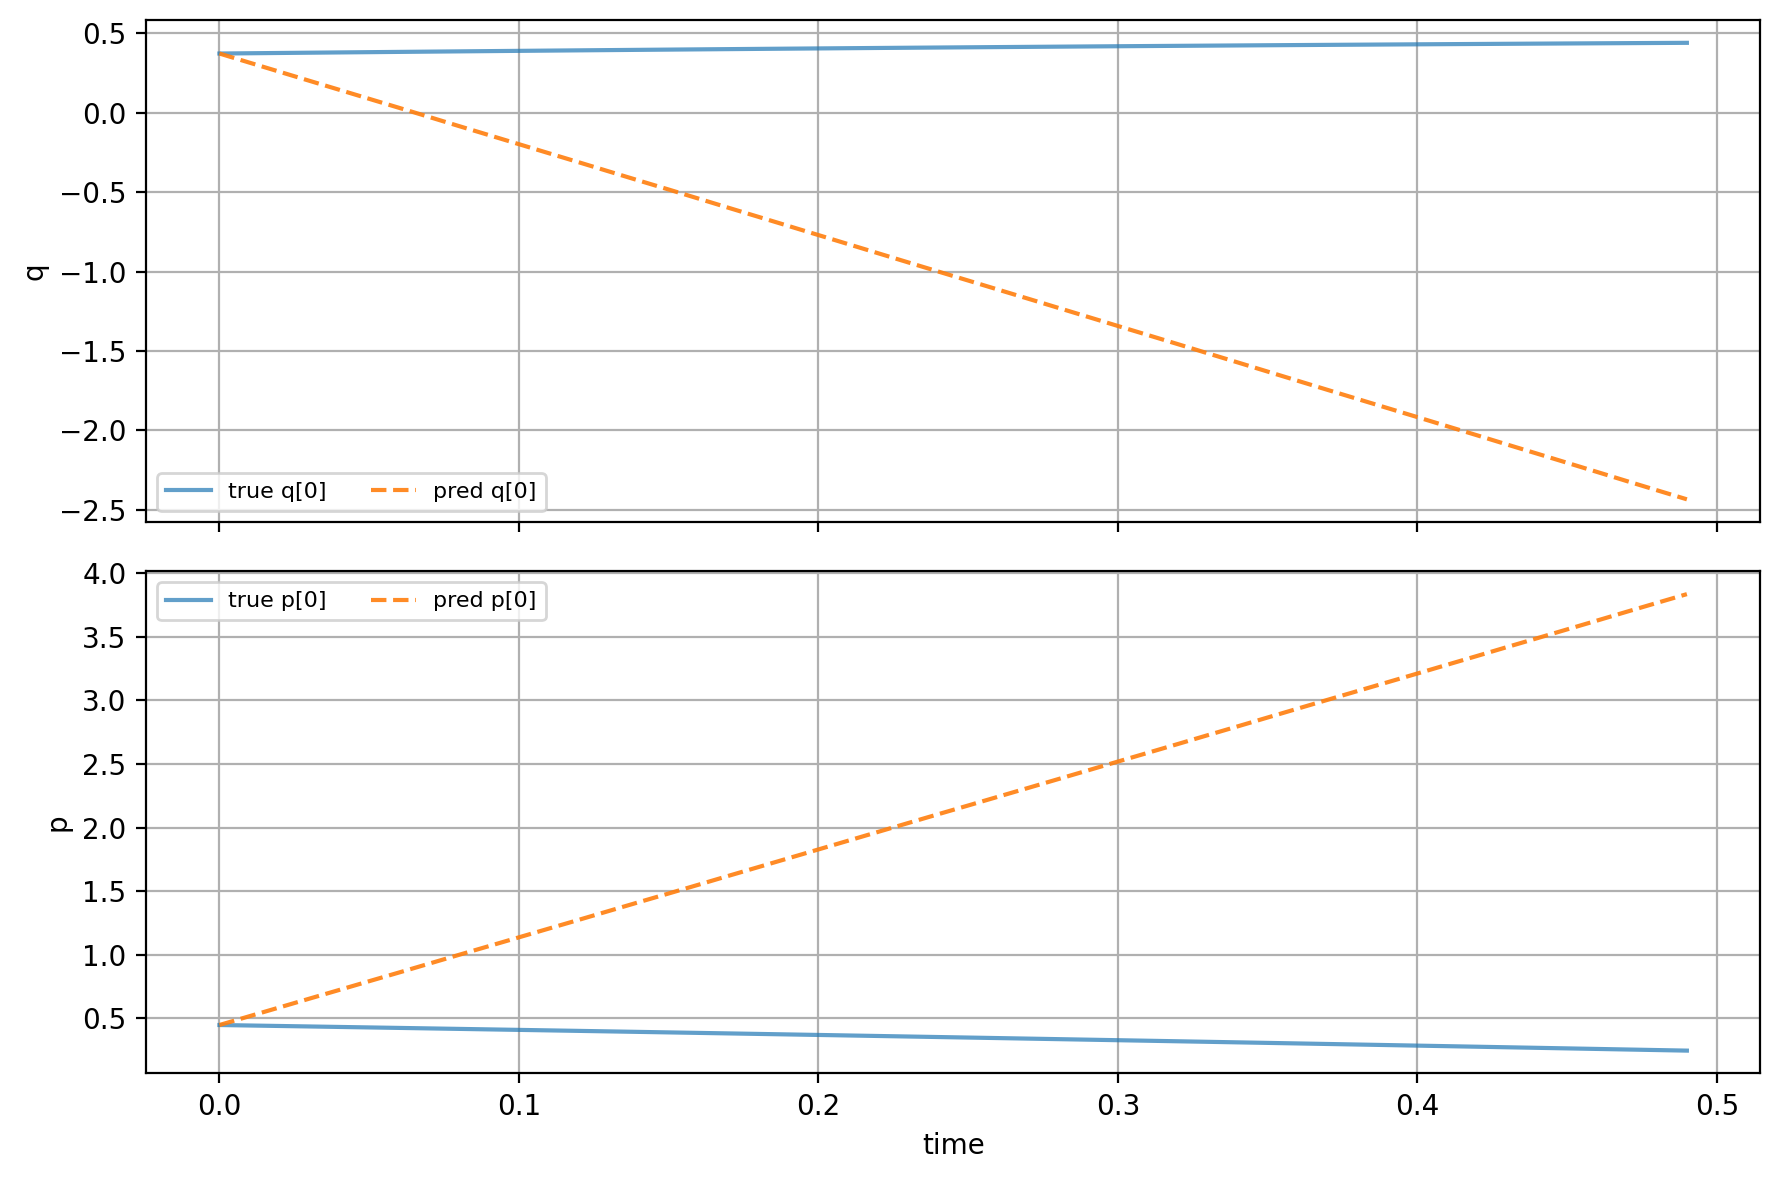

In [25]:

# --- 真値 vs モデル予測（同一初期値）---


#Ts = tuple(np.random.randint(500, 1500, size=(B,)).tolist())


T_total = 50  # 欲しいステップ数に合わせて調整

Ts = tuple(np.arange(0, T_total).tolist())

# q0 = q_true[:1]  # shape (1, n)
# p0 = p_true[:1]
# delta_t_infer = jnp.asarray(dt)

train_idx = 10000
q0 = train_dataset[0][train_idx:train_idx+1, :n]  # shape (1, n)
p0 = train_dataset[0][train_idx:train_idx+1, n:]
delta_t_infer = train_dataset[3][train_idx:train_idx+1]
print(delta_t_infer)

t_vec, q_true, p_true, _ = flow_coupled_1d_harmonic_init_values(
    params=set_harmonic_params(n=n, m=m, k_wall=k_wall, k_pair=k_pair),
    num_steps=Ts,
    dt=dt,
    q0=q0,
    p0=p0,
)


def step_fn(carry, _):
    q_curr, p_curr = carry
    q_next, p_next, _, _ = model.apply(
        {'params': nn_params}, q_curr, p_curr, delta_t_infer, train=False
    )
    return (q_next, p_next), (q_next, p_next)

if T_total <= 1:
    q_pred = q0
    p_pred = p0
else:
    (_, _), (qs_seq, ps_seq) = jax.lax.scan(
        step_fn, (q0, p0), None, length=T_total - 1
    )
    if qs_seq.ndim == 3:
        qs_seq = jnp.squeeze(qs_seq, axis=1)
        ps_seq = jnp.squeeze(ps_seq, axis=1)
    q_pred = jnp.concatenate([q0, qs_seq], axis=0)
    p_pred = jnp.concatenate([p0, ps_seq], axis=0)

t_arr = np.asarray(t[:T_total])
q_true_np = np.asarray(q_true)[:T_total]
p_true_np = np.asarray(p_true)[:T_total]
q_pred_np = np.asarray(q_pred)
p_pred_np = np.asarray(p_pred)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

for i in range(q_pred_np.shape[1]):
    axes[0].plot(t_arr, q_true_np[:, i], label=f'true q[{i}]', alpha=0.7)
    axes[0].plot(t_arr, q_pred_np[:, i], '--', label=f'pred q[{i}]', alpha=0.9)
axes[0].set_ylabel('q')
axes[0].grid(True)
axes[0].legend(ncol=2, fontsize=8)

for i in range(p_pred_np.shape[1]):
    axes[1].plot(t_arr, p_true_np[:, i], label=f'true p[{i}]', alpha=0.7)
    axes[1].plot(t_arr, p_pred_np[:, i], '--', label=f'pred p[{i}]', alpha=0.9)
axes[1].set_ylabel('p')
axes[1].set_xlabel('time')
axes[1].grid(True)
axes[1].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()



# Diagnostics

We compare our model to the ground truth Hamiltonian:
\begin{equation}
H(q, p)=\sum_{i=1}^n \frac{p_i^2}{2 m_i}+\frac{k_{\text {wall }}}{2} \sum_{i=1}^n q_i^2+\frac{k_{\text {pair }}}{2} \sum_{1 \leq i < j \leq n} \left( q_i-q_j \right)^2, 
\end{equation}
or
\begin{align}
H =~& \frac{1}{2} p^\top M p + \frac{1}{2} q^\top\left(k_{\mathrm{wall}} I+k_{\mathrm{pair}}\left(n I-\mathbf{1 1}^{\top}\right)\right) q \\
=~&  \frac{1}{2} p^\top M p + \frac{1}{2} q^\top K q
\end{align}
and the ground truth action and anlge:
\begin{equation}
I_j = \frac{1}{2\omega_j} (p)
\end{equation}
(unfinished cell)

In [38]:

# --- Hamiltonian diagnostics utilities ---
import numpy as _np

def _make_m_k(sim_params):
    n_loc = int(sim_params.n)
    m_loc = _np.asarray(sim_params.m, dtype=float)
    k_wall_loc = float(sim_params.k_wall)
    k_pair_loc = float(sim_params.k_pair)
    M = _np.diag(m_loc)
    J = _np.ones((n_loc, n_loc))
    K = k_wall_loc * _np.eye(n_loc) + k_pair_loc * (n_loc * _np.eye(n_loc) - J)
    return M, K

def H_ground_truth(q_arr, p_arr, sim_params):
    q_arr = _np.atleast_2d(_np.asarray(q_arr))
    p_arr = _np.atleast_2d(_np.asarray(p_arr))
    M, K = _make_m_k(sim_params)
    Minv = _np.linalg.inv(M)
    kin = 0.5 * _np.einsum('ti,ij,tj->t', p_arr, Minv, p_arr)
    pot = 0.5 * _np.einsum('ti,ij,tj->t', q_arr, K, q_arr)
    return kin + pot

def action_angle_ground_truth(q_arr, p_arr, sim_params):
    q_arr = _np.atleast_2d(_np.asarray(q_arr))
    p_arr = _np.atleast_2d(_np.asarray(p_arr))
    n_loc = int(sim_params.n)
    m_loc = _np.asarray(sim_params.m, dtype=float)
    M = _np.diag(m_loc)
    Minv_sqrt = _np.diag(1.0 / _np.sqrt(m_loc))
    Msqrt = _np.diag(_np.sqrt(m_loc))
    _, K = _make_m_k(sim_params)
    A = Minv_sqrt @ K @ Minv_sqrt
    w2, U = _np.linalg.eigh(A)
    omega = _np.sqrt(_np.clip(w2, a_min=0.0, a_max=None))
    y = (Msqrt @ q_arr.T).T
    pi = (Minv_sqrt @ p_arr.T).T
    xi = (U.T @ y.T).T
    rho = (U.T @ pi.T).T
    omega_safe = _np.where(omega > 0, omega, 1.0)
    I = 0.5 * ((rho ** 2) + (omega[None, :] ** 2) * (xi ** 2)) / omega_safe[None, :]
    theta = _np.arctan2(omega[None, :] * xi, rho)
    return I, theta, omega, U

def predict_hamiltonian(nn_params,q_arr, p_arr):
    q_j = jnp.asarray(q_arr)
    p_j = jnp.asarray(p_arr)
    if q_j.ndim == 1:
        q_j = q_j[None, :]
    if p_j.ndim == 1:
        p_j = p_j[None, :]
    H_pred = model.apply({'params': nn_params}, q_j, p_j,
                         method=MyActionAngleNetwork.hamiltonian)
    return _np.asarray(H_pred)

def predict_action_angle(nn_params, q_arr, p_arr):
    q_j = jnp.asarray(q_arr)
    p_j = jnp.asarray(p_arr)
    if q_j.ndim == 1:
        q_j = q_j[None, :]
    if p_j.ndim == 1:
        p_j = p_j[None, :]
    _, _, I_pred, theta_pred = model.apply({'params': nn_params}, q_j, p_j,
                                           jnp.asarray(0.0), train=False)
    return _np.asarray(I_pred), _np.asarray(theta_pred)



In [39]:
theta_pred_vals

NameError: name 'theta_pred_vals' is not defined

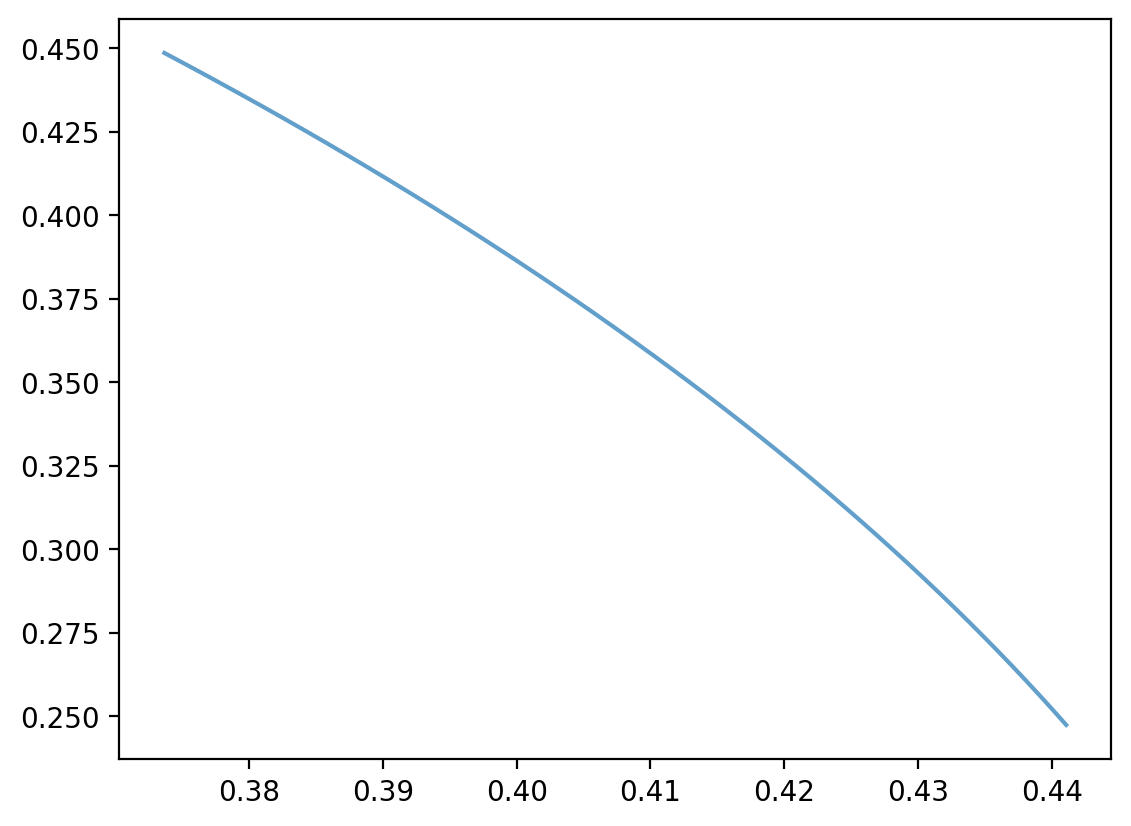

In [ ]:
plt.plot(q_true_np, p_true_np, label='True Trajectory', alpha=0.7)

2025-11-04 09:22:37.218265: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-11-04 09:22:38.027276: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


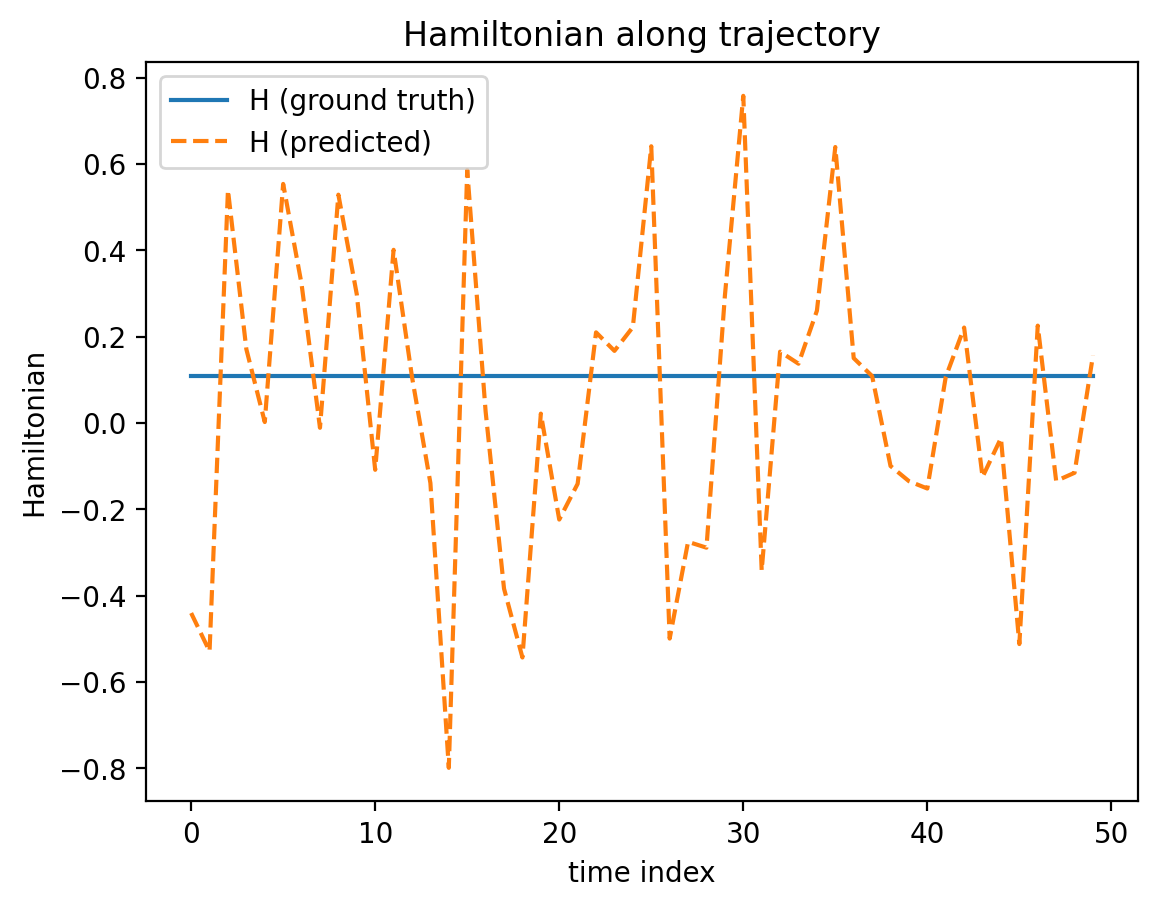

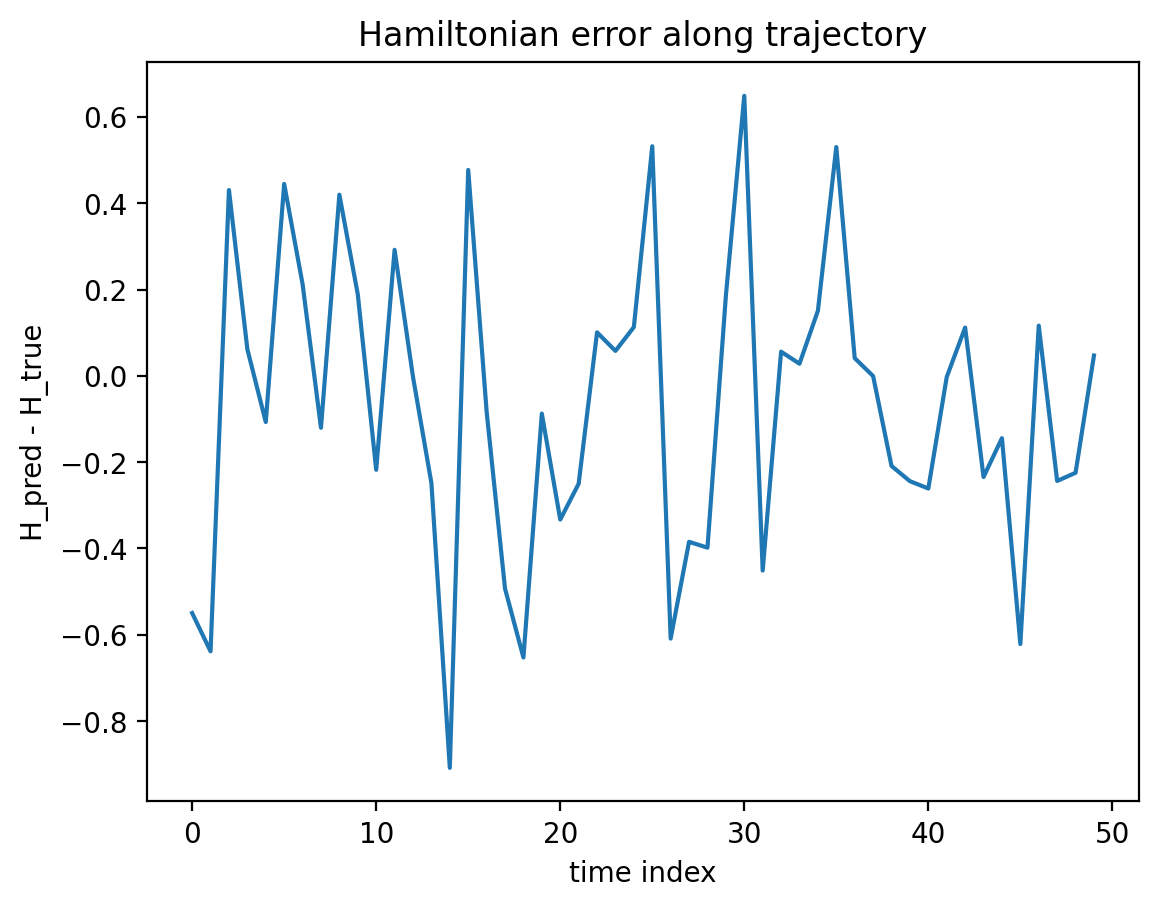

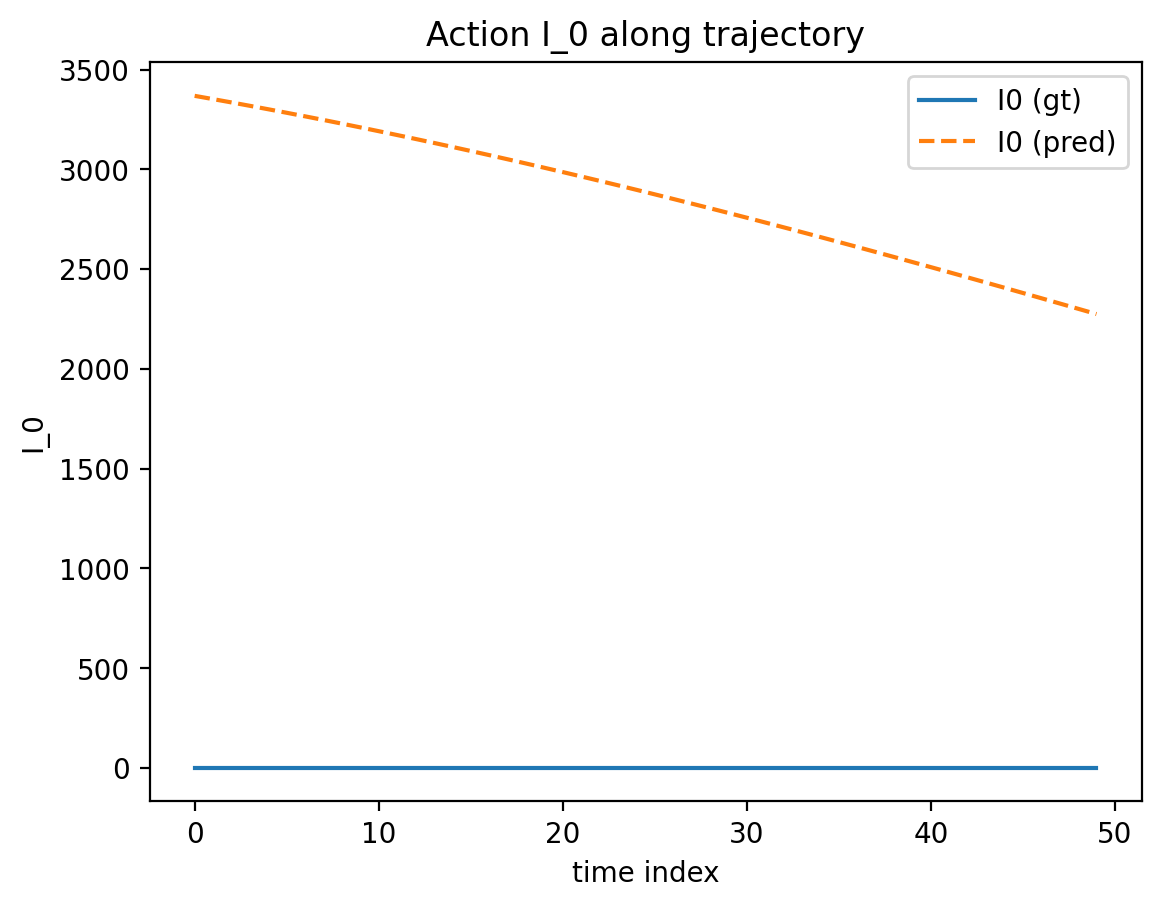

IndexError: too many indices for array: array is 0-dimensional, but 2 were indexed

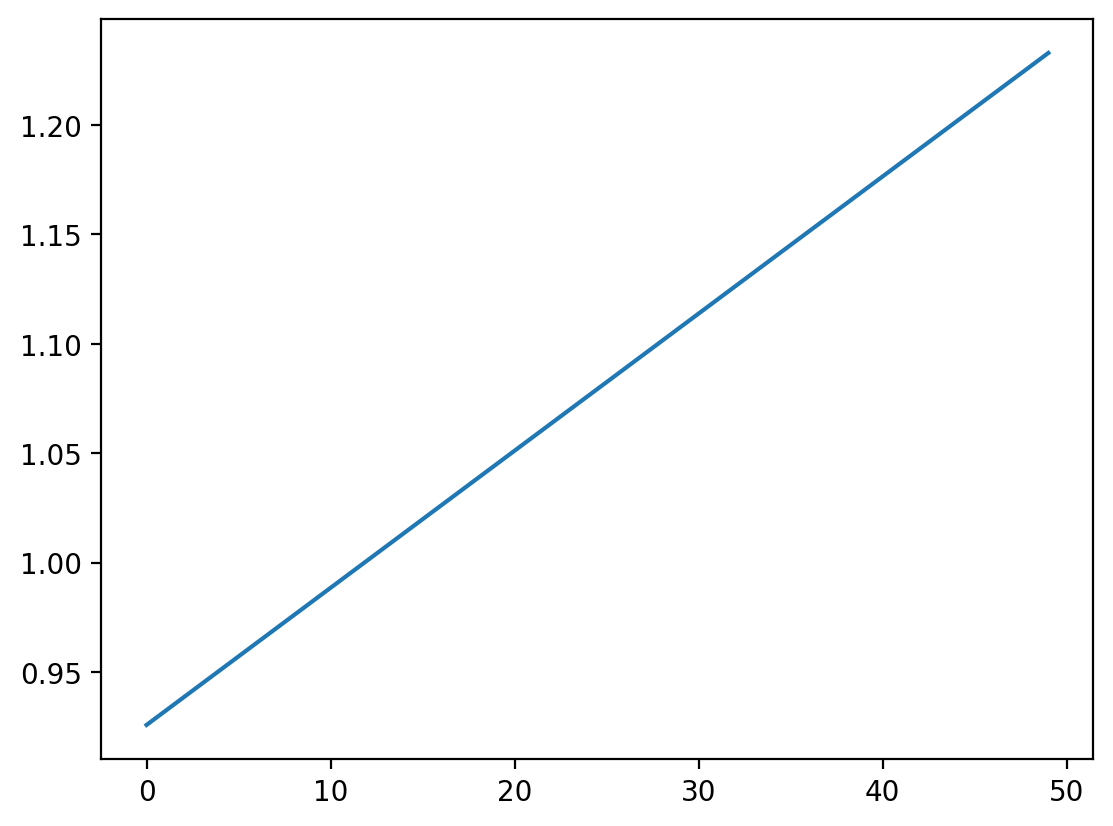

In [ ]:

# --- Hamiltonian / action diagnostics ---
sim_params = hyper_params

q_plot = _np.asarray(q_true_np)
p_plot = _np.asarray(p_true_np)

H_true_vals = H_ground_truth(q_plot, p_plot, sim_params)
I_true_vals, theta_true_vals, omega_vals, U_vals = action_angle_ground_truth(q_plot, p_plot, sim_params)

H_pred_vals = predict_hamiltonian(nn_params, q_plot, p_plot)
I_pred_vals, theta_pred_vals = predict_action_angle(nn_params, q_plot, p_plot)

plt.figure()
plt.plot(H_true_vals, label='H (ground truth)')
plt.plot(H_pred_vals, '--', label='H (predicted)')
plt.xlabel('time index')
plt.ylabel('Hamiltonian')
plt.title('Hamiltonian along trajectory')
plt.legend()
plt.show()

plt.figure()
plt.plot(H_pred_vals - H_true_vals)
plt.xlabel('time index')
plt.ylabel('H_pred - H_true')
plt.title('Hamiltonian error along trajectory')
plt.show()

max_modes = min(4, I_true_vals.shape[1])
for j_mode in range(max_modes):
    plt.figure()
    plt.plot(I_true_vals[:, j_mode], label=f'I{j_mode} (gt)')
    plt.plot(I_pred_vals[:, j_mode], '--', label=f'I{j_mode} (pred)')
    plt.xlabel('time index')
    plt.ylabel(f'I_{j_mode}')
    plt.title(f'Action I_{j_mode} along trajectory')
    plt.legend()
    plt.show()

def _wrap_pi(arr):
    return (arr + np.pi) % (2 * np.pi) - np.pi

for j_mode in range(max_modes):
    plt.figure()
    plt.plot(_wrap_pi(theta_true_vals[:, j_mode]), label=f'theta{j_mode} (gt)')
    plt.plot(_wrap_pi(theta_pred_vals[:, j_mode]), '--', label=f'theta{j_mode} (pred)')
    plt.xlabel('time index')
    plt.ylabel(f'theta_{j_mode}')
    plt.title(f'Angle theta_{j_mode} along trajectory')
    plt.legend()
    plt.show()



In [ ]:
# 検証用: n=1, B=4, dt=0.01
sample_steps = jnp.array([1, 2, 5, 10, 50], dtype=int)
q0 = jnp.array([[1.0], [0.5], [-0.3], [0.0], [2.0]])
p0 = jnp.array([[0.0], [0.2], [-0.1], [0.4], [-0.5]])

t_flow, q_flow, p_flow, _ = flow_coupled_1d_harmonic_init_values(
    params=hyper_params, num_steps=tuple(sample_steps.tolist()),
    dt=dt, q0=q0, p0=p0)

x0, x0_dot, xt, t_dataset = create_dataset(
    x0=jnp.concatenate([q0, p0], axis=1),
    steps=sample_steps, dt=dt, hyper_params=hyper_params)

print(jnp.allclose(t_flow, t_dataset))
print(jnp.allclose(q_flow, xt[:, :1]))
print(jnp.allclose(p_flow, xt[:, 1:]))


/tmp/1022703.6288/ipykernel_245008/915626916.py:186: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  t = jnp.array([ns * float(dt) for ns in num_steps], dtype=jnp.float64) # shape (B,)


True
True
True


In [ ]:
print(x0)

[[ 1.   0. ]
 [ 0.5  0.2]
 [-0.3 -0.1]
 [ 0.   0.4]]


In [30]:
q0

Array([[0.3736453]], dtype=float32)

In [31]:
p0

Array([[0.4485712]], dtype=float32)

In [32]:
model.apply({'params':nn_params}, q0, p0, 0.0)

(Array([[0.37347534]], dtype=float32),
 Array([[0.44877633]], dtype=float32),
 Array([[3368.1235]], dtype=float32),
 None)

In [33]:
qs_test = jax.random.uniform(q_test_key, shape=(N_test, n), minval=-3.0, maxval=3.0)
ps_test = jax.random.uniform(p_test_key, shape=(N_test, n), minval=-3.0, maxval=3.0)

qs_test_tobe, ps_test_tobe, *_ = model.apply({'params':nn_params}, qs_test, ps_test, 0.0)

In [34]:
print(qs_test, qs_test_tobe)

[[ 2.72219   ]
 [ 1.4835758 ]
 [-0.48492408]
 ...
 [ 2.462976  ]
 [-1.0109532 ]
 [ 1.5638795 ]] [[ 2.7244248 ]
 [ 1.4839691 ]
 [-0.48489994]
 ...
 [ 2.4626281 ]
 [-1.0110245 ]
 [ 1.5638812 ]]


In [35]:
jnp.linalg.norm(qs_test - qs_test_tobe) / jnp.linalg.norm(qs_test)

Array(0.00047176, dtype=float32)

In [36]:
jnp.linalg.norm(ps_test - ps_test_tobe) / jnp.linalg.norm(ps_test)

Array(0.0005692, dtype=float32)

In [37]:
model.apply({'params':nn_params}, q0, p0, 0.0)

(Array([[0.37347534]], dtype=float32),
 Array([[0.44877633]], dtype=float32),
 Array([[3368.1235]], dtype=float32),
 None)

In [38]:
# Access scale_q through the apply method
#variables = model.init(jax.random.PRNGKey(0), jnp.zeros((1, n)), jnp.zeros((1, n)), jnp.asarray(0.1))
scale_q = model.apply(variables, method=lambda mdl: mdl.scale_q)
scale_q

Array([1.], dtype=float32)

In [39]:
scale_p = model.apply(variables, method=lambda mdl: mdl.scale_p)
print(scale_p)

[1.]


In [40]:
from flax.traverse_util import flatten_dict
loss, grads = value_and_grad(loss_fn)(params)

fd = flatten_dict(grads, sep='/')
{k: jnp.linalg.norm(v) for k, v in fd.items() if 'scale' in '/'.join(k)}
# 期待：{'.../log_scale_q': 非ゼロ,  '.../log_scale_p': 非ゼロ}


NameError: name 'loss_fn' is not defined

# Previous way of training (use long trajectory)

In [41]:
# t, q, p は前セルのシミュレーション出力。q, p の shape は (T, n)
T_steps = 1000
t, q, p, aux = flow_coupled_1d_harmonic_init_values(
    params=set_harmonic_params(n=n, m=m, k_wall=k_wall, k_pair=k_pair),
    num_steps=tuple(np.arange(0, T_steps).tolist()),
    dt=dt,
    q0=jax.random.normal(jax.random.PRNGKey(0), (1,n)),
    p0=jax.random.normal(jax.random.PRNGKey(0), (1,n)),
)


# 時系列で分割（情報漏洩を防ぐため、時間で切る）
frac_train = 0.1
frac_test  = 0.5

T_train = int(T_steps * frac_train)
T_test  = int(T * frac_test)

q_train = jnp.asarray(q[:T_train])
p_train = jnp.asarray(p[:T_train])

q_test  = jnp.asarray(q[-T_test:])
p_test  = jnp.asarray(p[-T_test:])

/tmp/1022852.1790/ipykernel_188506/915626916.py:186: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  t = jnp.array([ns * float(dt) for ns in num_steps], dtype=jnp.float64) # shape (B,)


In [42]:
@jit
def train_step_old(params, opt_state, x, y, delta_t, alpha, key):
    # x: (B, 2n) current (q, p)
    # y: (B, 2n) target  (q, p)
    T = x.shape[0]
    n = x.shape[1] // 2
    q, p = x[:, :n], x[:, n:]  # (B, n), (B, n)

    def loss_fn(pp):
        q_, p_, I, _ = model.apply({'params': pp}, q, p, delta_t, train=True, rngs={'noise': key})
        #x_ = jnp.concatenate([q_, p_], axis=-1)
        # q_, p_: (B, n), (B, n)
        # I: (B, n) actions
        
        # prediction loss
        loss_q_se = (1./(1.+delta_t))*((q_ - y[:, :n]) ** 2).sum()#.mean()
        loss_p_se = (1./(1.+delta_t))*((p_ - y[:, n:]) ** 2).sum()#.mean()

        # actions should be constant
        loss_action = jnp.var(I, axis=0).sum()

        return loss_q_se + loss_p_se + alpha * loss_action

    loss, grads = value_and_grad(loss_fn)(params)
    updates, opt_state = tx.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

@jit
def eval_batch_old(params, x, y, delta_t, key):
    n = x.shape[1] // 2
    q, p = x[:, :n], x[:, n:]  # (B, 3), (B, 3)
    
    q_, p_, _, _ = model.apply({'params': params}, q, p, delta_t, train=False, rngs={'noise': key})
    #x_ = jnp.concatenate([q_, p_], axis=-1)

    loss_q_mse = ((q_ - y[:, :n]) ** 2).mean()
    loss_p_mse = ((p_ - y[:, n:]) ** 2).mean()

    return loss_q_mse + loss_p_mse


In [43]:
num_steps = 5000
delta_t_max = dt*10 # maximum jump (see Eq.(10) in the paper)

batch_size = 100
log_every = 100
test_time_jumps = [1,2,5,10,20,50]
alpha = 1 #0.5  # weight for action constancy loss

normalize_qp = True

key = random.PRNGKey(0)
eval_key  = random.PRNGKey(42)


print("Start training...")
print(f"num_steps: {num_steps}, delta_t_max: {delta_t_max}, batch_size: {batch_size}, log_every: {log_every}")
print(f"test_time_jumps: {test_time_jumps}")
print(f"alpha (weight for action constancy loss): {alpha}")


for step in range(1, num_steps + 1):
    rng, sub1, sub2, sub3 = jax.random.split(rng, 4)

    # jump幅をサンプル
    max_time_jump_for_step = 1 + (step / num_steps) * (delta_t_max - 1)
    jump = jax.random.randint(sub1, shape=(), minval=1, maxval=max_time_jump_for_step + 1)
    # jump_max = jax.random.randint(sub1, shape=(), minval=1, maxval=int( step/num_steps * delta_t_max ) + 1 )
    # jump = jax.random.randint(sub2, shape=(), minval=1, maxval=jump_max+1)
    # jumpはあくまでステップ幅であり実時間ではない、実時間を計算
    delta_t_scalar = jnp.asarray(dt * jump)

    # n_train - jump このペアを作る
    curr_q, curr_p = q_train[:-jump], p_train[:-jump]
    tgt_q, tgt_p = q_train[jump:], p_train[jump:]

    # 重複を許してbatch_size個サンプル
    batch_size = min(batch_size, curr_q.shape[0]) # curr_qの数がとても小さいときはそれを上限にする
    idx_sample = jax.random.choice(
        sub3, curr_q.shape[0], shape=(batch_size,), replace=False
    )
    batch = (
        curr_q[idx_sample], curr_p[idx_sample],
        tgt_q[idx_sample], tgt_p[idx_sample],
    )

    #batch = sample_train_batch(sub)
    # batch = train_curr_q[idx], train_curr_p[idx], train_tgt_q[idx],  train_tgt_p[idx],

    params, opt_state, train_loss = train_step_old(
        params=params,
        opt_state=opt_state,
        x=jnp.concatenate([batch[0], batch[1]], axis=-1),
        y=jnp.concatenate([batch[2], batch[3]], axis=-1),
        alpha=alpha,
        delta_t=delta_t_scalar,
        key=rng
    )

    if step % log_every == 0 or step == 1:

        test_loss_list = []
        for jump in test_time_jumps:
            test_curr_q, test_curr_p = q_test[:-jump], p_test[:-jump] # (T-jump, n)
            test_tgt_q, test_tgt_p = q_test[jump:], p_test[jump:] # (T-jump, n)
            delta_t_test = dt * jump
            test_loss_jump = eval_batch_old(
                params=params,
                x=jnp.concatenate([test_curr_q, test_curr_p], axis=-1), 
                y=jnp.concatenate([test_tgt_q, test_tgt_p], axis=-1),
                delta_t=delta_t_test,
                key=eval_key
            )
            test_loss_list.append(test_loss_jump)
        
        test_str = ", ".join(f"jump={j}: {float(l):.6f}"
                            for j, l in zip(test_time_jumps, test_loss_list))
        print(f"step {step:5d}  train_loss {float(train_loss):.6f}  test_loss [{test_str}]")

        # print(f"step {step:5d}  train_loss {float(train_loss):.6f}  test_loss {float(test_loss_list):.6f}")
        # wandb.log({
        #     "train/loss": float(train_loss),
        #     "test/loss": float(test_loss),
        #     "step": step,
        # })



        # for jump in test_time_jumps:
        #     test_curr_q.append( q_test[:-jump] )
        #     test_curr_p.append( p_test[:-jump] )
        #     test_tgt_q.append( q_test[jump:] )
        #     test_tgt_p.append( p_test[jump:] )
        #     delta_t_test.append(jnp.repeat(dt * jump, q_test.shape[0]-jump))
        # test_curr_q = jnp.concatenate(test_curr_q, axis=0)
        # test_curr_p = jnp.concatenate(test_curr_p, axis=0)
        # test_tgt_q  = jnp.concatenate(test_tgt_q, axis=0)
        # test_tgt_p  = jnp.concatenate(test_tgt_p, axis=0)
        # delta_t_test = jnp.concatenate(delta_t_test, axis=0)

        
        # test_loss = eval_batch(
        #     params=params,
        #     x=jnp.concatenate([test_curr_q, test_curr_p], axis=-1), 
        #     y=jnp.concatenate([test_tgt_q, test_tgt_p], axis=-1),
        #     delta_t=delta_t_test,
        #     key=eval_key
        # )
        

Start training...
num_steps: 5000, delta_t_max: 0.1, batch_size: 100, log_every: 100
test_time_jumps: [1, 2, 5, 10, 20, 50]
alpha (weight for action constancy loss): 1


2025-11-04 09:22:54.187176: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-11-04 09:22:54.187212: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-11-04 09:22:54.187225: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


step     1  train_loss 5024417579008.000000  test_loss [jump=1: 1849276928.000000, jump=2: 7438972416.000000, jump=5: 45689909248.000000, jump=10: 179982352384.000000, jump=20: 696266653696.000000, jump=50: 3344634740736.000000]
step   100  train_loss 119529.484375  test_loss [jump=1: 779753.312500, jump=2: 2351324.000000, jump=5: 8990124.000000, jump=10: 22998004.000000, jump=20: 42378848.000000, jump=50: 2094068.500000]
step   200  train_loss 38233.910156  test_loss [jump=1: 113561.234375, jump=2: 378576.187500, jump=5: 1662701.750000, jump=10: 4807455.500000, jump=20: 13134210.000000, jump=50: 40345208.000000]
step   300  train_loss 28353.804688  test_loss [jump=1: 6713.489258, jump=2: 26138.378906, jump=5: 146524.656250, jump=10: 484117.906250, jump=20: 1492221.375000, jump=50: 6334259.500000]
step   400  train_loss 27790.851562  test_loss [jump=1: 214.652740, jump=2: 813.516968, jump=5: 4857.356445, jump=10: 19213.607422, jump=20: 73736.390625, jump=50: 397607.093750]
step   500  

/tmp/1022852.1790/ipykernel_188506/915626916.py:186: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  t = jnp.array([ns * float(dt) for ns in num_steps], dtype=jnp.float64) # shape (B,)


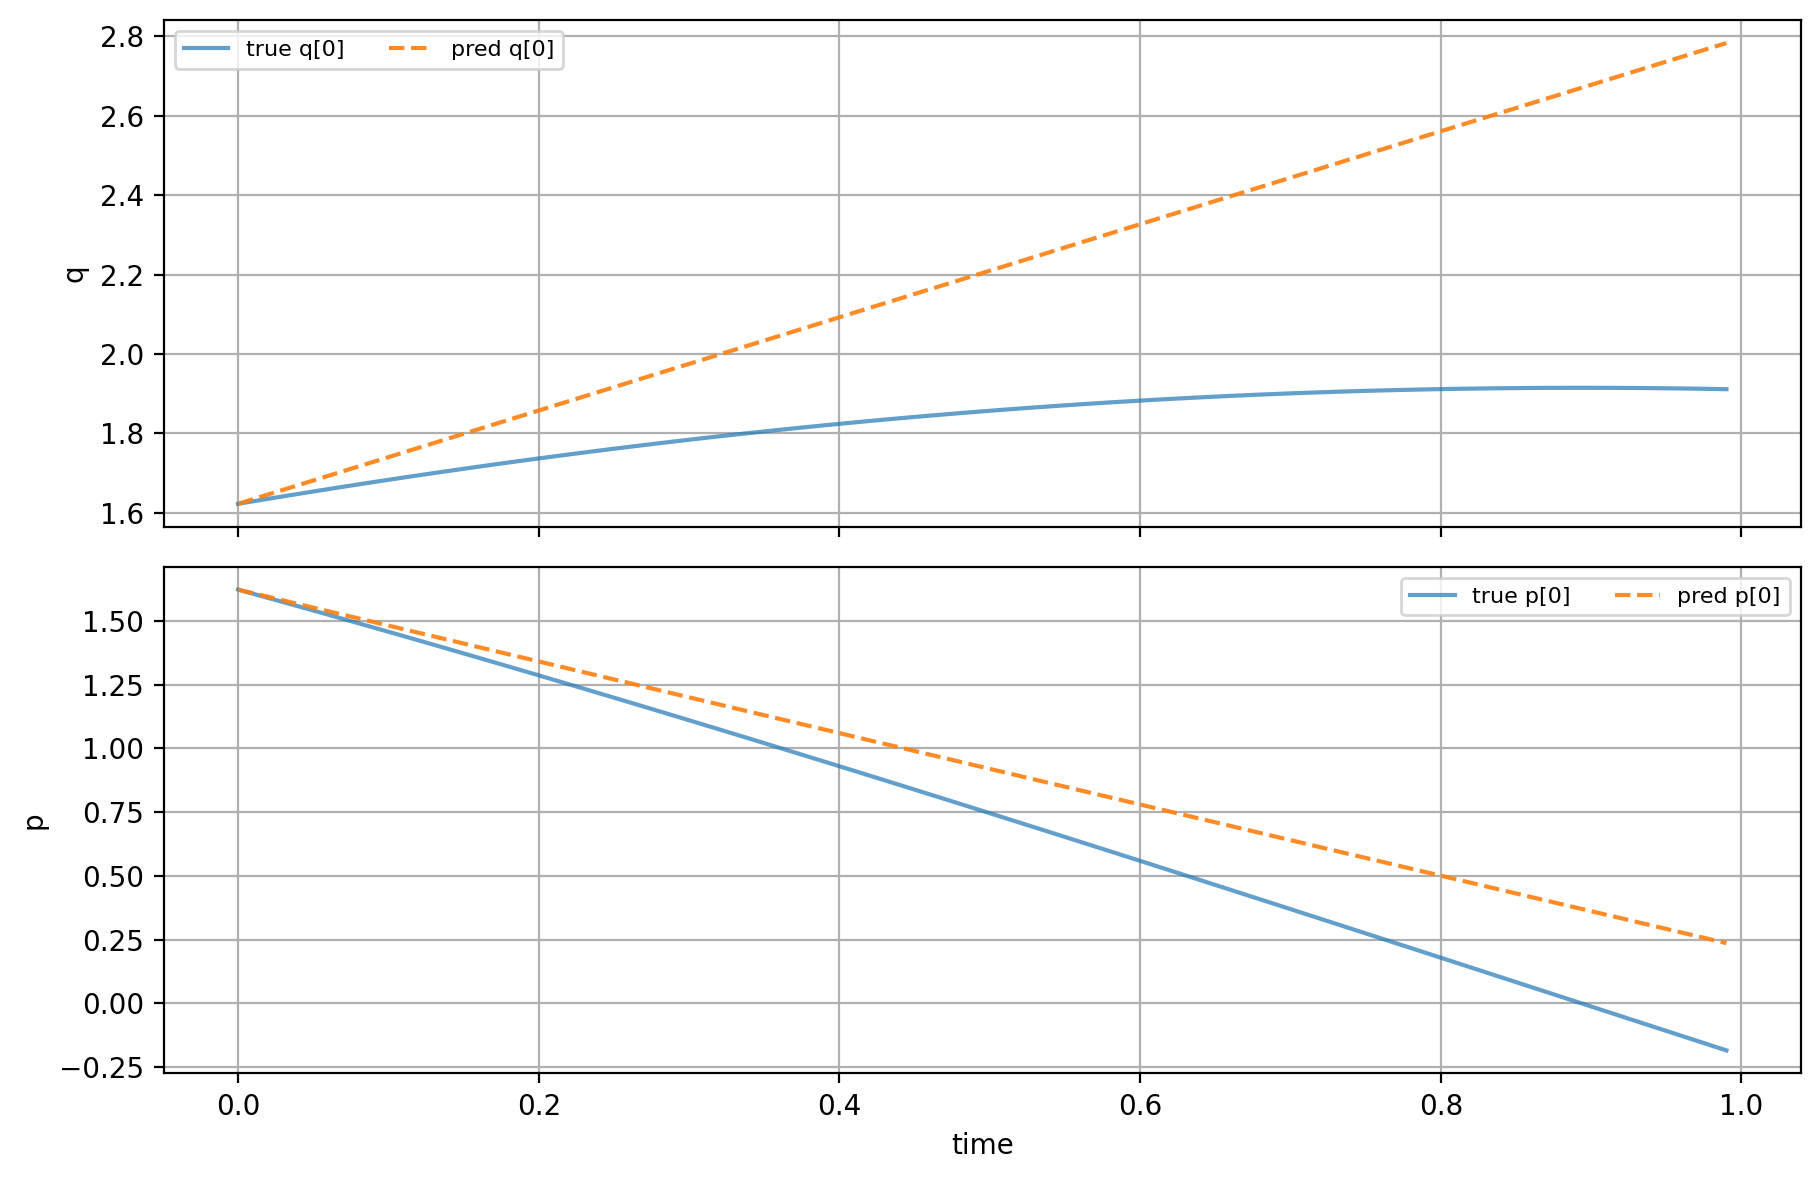

In [44]:

T_total = 100  # 欲しいステップ数に合わせて調整

t_vec, q_true, p_true, _ = flow_coupled_1d_harmonic_init_values(
    params=set_harmonic_params(n=n, m=m, k_wall=k_wall, k_pair=k_pair),
    num_steps=tuple(np.arange(0, T_total).tolist()),
    dt=dt,
    q0=jax.random.normal(jax.random.PRNGKey(0), (1,n)),
    p0=jax.random.normal(jax.random.PRNGKey(0), (1,n)),
)

q0 = q_true[:1]  # shape (1, n)
p0 = p_true[:1]
delta_t_infer = jnp.asarray(dt)

def step_fn(carry, _):
    q_curr, p_curr = carry
    q_next, p_next, _, _ = model.apply(
        {'params': params}, q_curr, p_curr, delta_t_infer, train=False
    )
    return (q_next, p_next), (q_next, p_next)

if T_total <= 1:
    q_pred = q0
    p_pred = p0
else:
    (_, _), (qs_seq, ps_seq) = jax.lax.scan(
        step_fn, (q0, p0), None, length=T_total - 1
    )
    if qs_seq.ndim == 3:
        qs_seq = jnp.squeeze(qs_seq, axis=1)
        ps_seq = jnp.squeeze(ps_seq, axis=1)
    q_pred = jnp.concatenate([q0, qs_seq], axis=0)
    p_pred = jnp.concatenate([p0, ps_seq], axis=0)

t_arr = np.asarray(t[:T_total])
q_true_np = np.asarray(q_true)[:T_total]
p_true_np = np.asarray(p_true)[:T_total]
q_pred_np = np.asarray(q_pred)
p_pred_np = np.asarray(p_pred)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

for i in range(q_pred_np.shape[1]):
    axes[0].plot(t_arr, q_true_np[:, i], label=f'true q[{i}]', alpha=0.7)
    axes[0].plot(t_arr, q_pred_np[:, i], '--', label=f'pred q[{i}]', alpha=0.9)
axes[0].set_ylabel('q')
axes[0].grid(True)
axes[0].legend(ncol=2, fontsize=8)

for i in range(p_pred_np.shape[1]):
    axes[1].plot(t_arr, p_true_np[:, i], label=f'true p[{i}]', alpha=0.7)
    axes[1].plot(t_arr, p_pred_np[:, i], '--', label=f'pred p[{i}]', alpha=0.9)
axes[1].set_ylabel('p')
axes[1].set_xlabel('time')
axes[1].grid(True)
axes[1].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()



2025-11-04 09:24:18.987519: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-11-04 09:24:19.827705: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


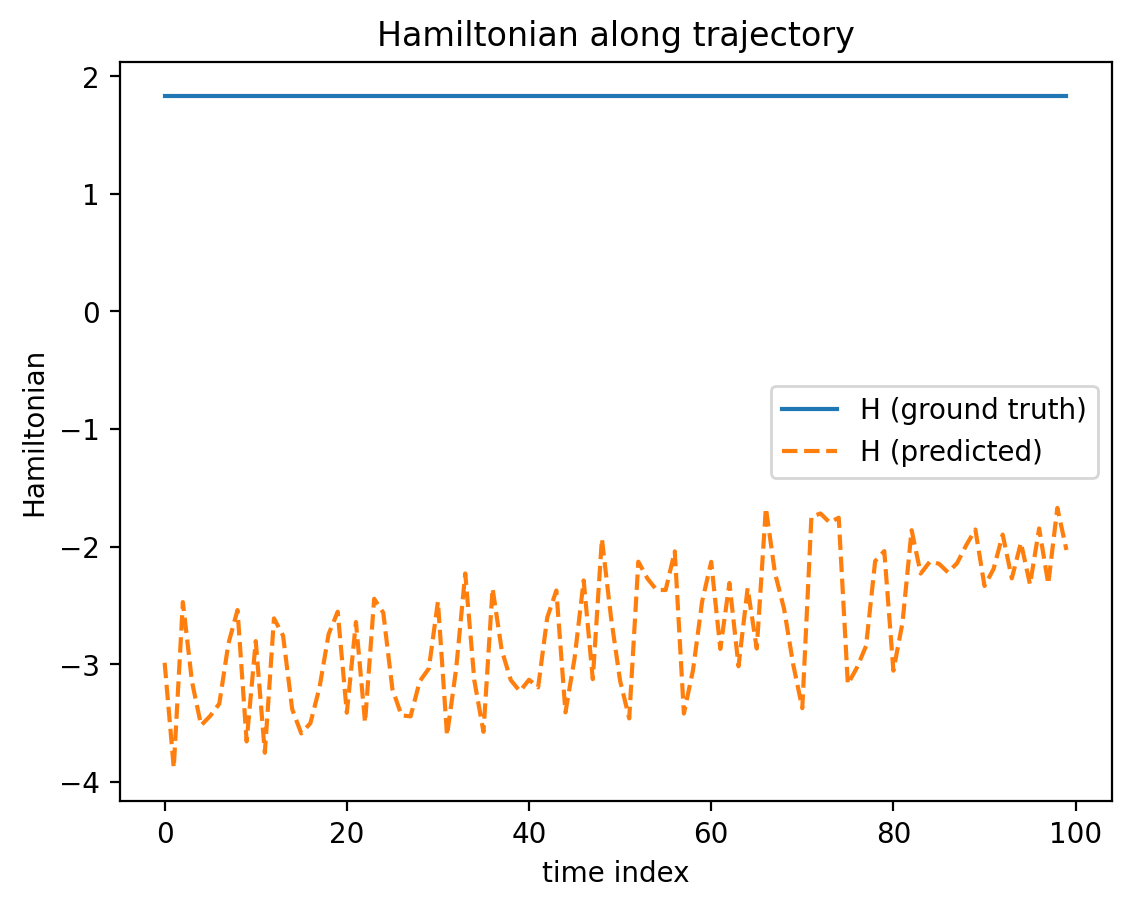

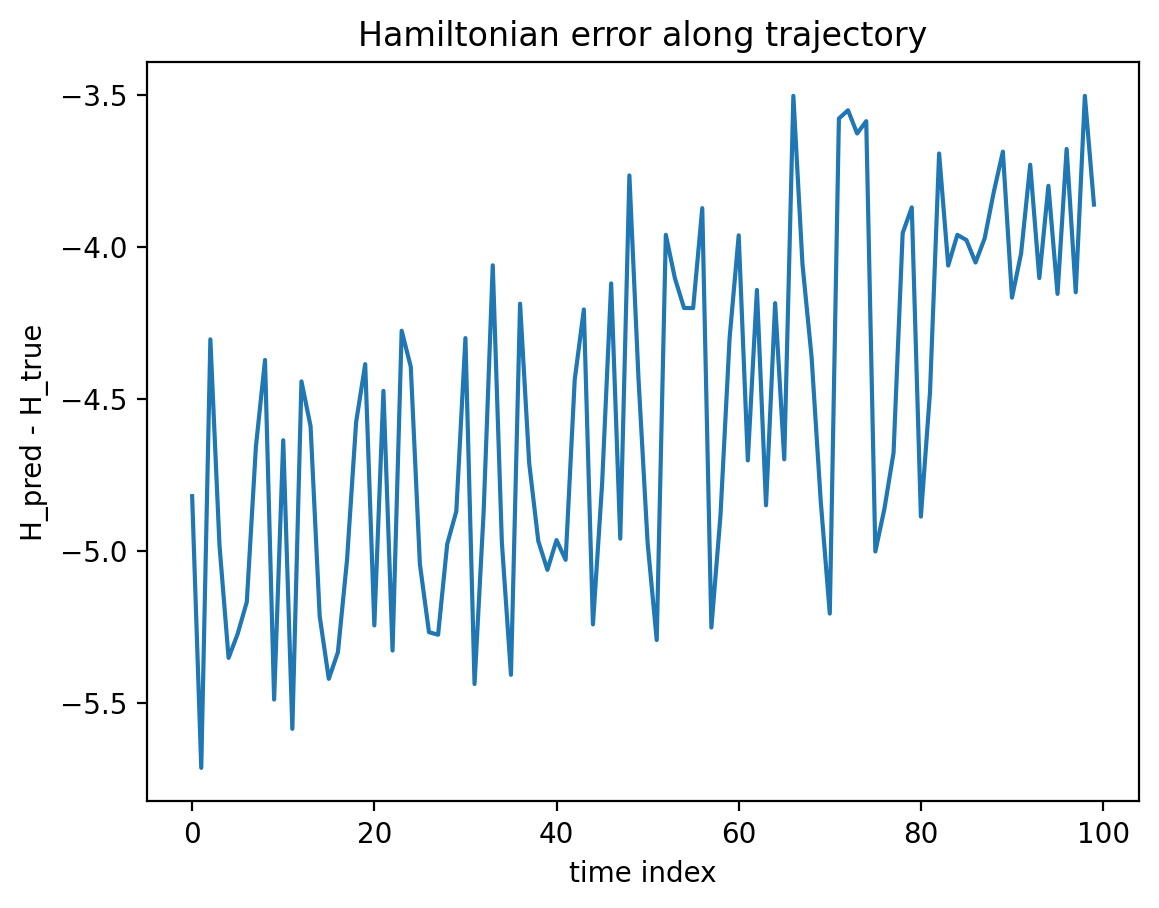

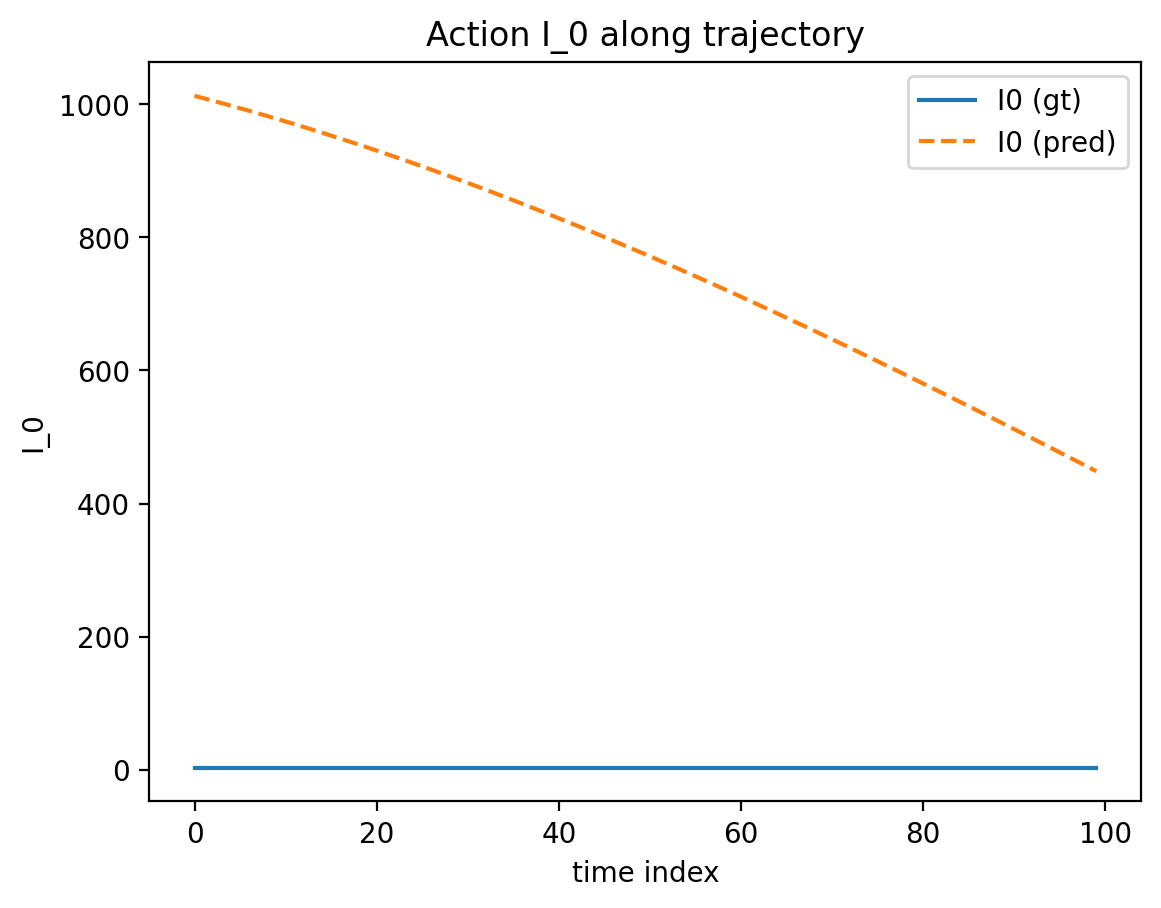

IndexError: too many indices for array: array is 0-dimensional, but 2 were indexed

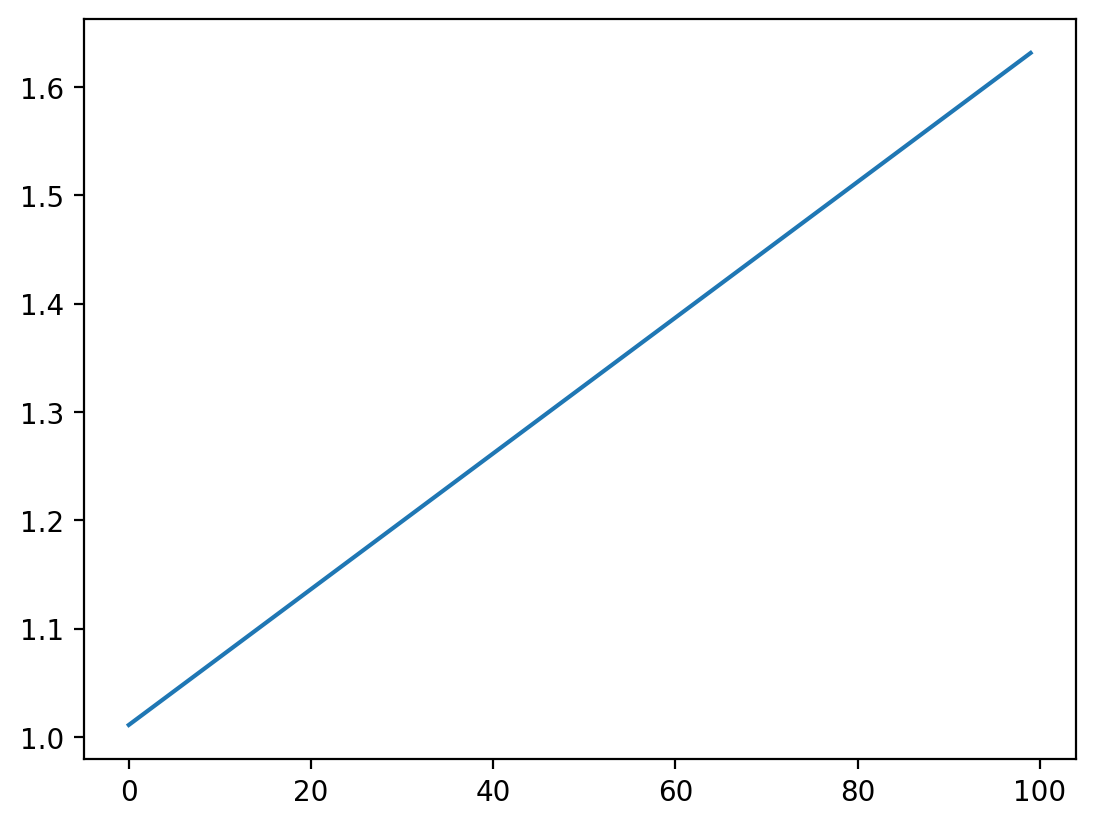

In [45]:

# --- Hamiltonian / action diagnostics ---
sim_params = hyper_params

q_plot = _np.asarray(q_true_np)
p_plot = _np.asarray(p_true_np)

H_true_vals = H_ground_truth(q_plot, p_plot, sim_params)
I_true_vals, theta_true_vals, omega_vals, U_vals = action_angle_ground_truth(q_plot, p_plot, sim_params)

H_pred_vals = predict_hamiltonian(params, q_plot, p_plot)
I_pred_vals, theta_pred_vals = predict_action_angle(params, q_plot, p_plot)

plt.figure()
plt.plot(H_true_vals, label='H (ground truth)')
plt.plot(H_pred_vals, '--', label='H (predicted)')
plt.xlabel('time index')
plt.ylabel('Hamiltonian')
plt.title('Hamiltonian along trajectory')
plt.legend()
plt.show()

plt.figure()
plt.plot(H_pred_vals - H_true_vals)
plt.xlabel('time index')
plt.ylabel('H_pred - H_true')
plt.title('Hamiltonian error along trajectory')
plt.show()

max_modes = min(4, I_true_vals.shape[1])
for j_mode in range(max_modes):
    plt.figure()
    plt.plot(I_true_vals[:, j_mode], label=f'I{j_mode} (gt)')
    plt.plot(I_pred_vals[:, j_mode], '--', label=f'I{j_mode} (pred)')
    plt.xlabel('time index')
    plt.ylabel(f'I_{j_mode}')
    plt.title(f'Action I_{j_mode} along trajectory')
    plt.legend()
    plt.show()

def _wrap_pi(arr):
    return (arr + np.pi) % (2 * np.pi) - np.pi

for j_mode in range(max_modes):
    plt.figure()
    plt.plot(_wrap_pi(theta_true_vals[:, j_mode]), label=f'theta{j_mode} (gt)')
    plt.plot(_wrap_pi(theta_pred_vals[:, j_mode]), '--', label=f'theta{j_mode} (pred)')
    plt.xlabel('time index')
    plt.ylabel(f'theta_{j_mode}')
    plt.title(f'Angle theta_{j_mode} along trajectory')
    plt.legend()
    plt.show()



# HHN

[HNN] Epoch 1/5  test MSE: 8.430323e-05
[HNN] Epoch 2/5  test MSE: 4.654130e-05
[HNN] Epoch 3/5  test MSE: 1.464958e-05
[HNN] Epoch 4/5  test MSE: 9.636425e-05
[HNN] Epoch 5/5  test MSE: 4.813221e-04


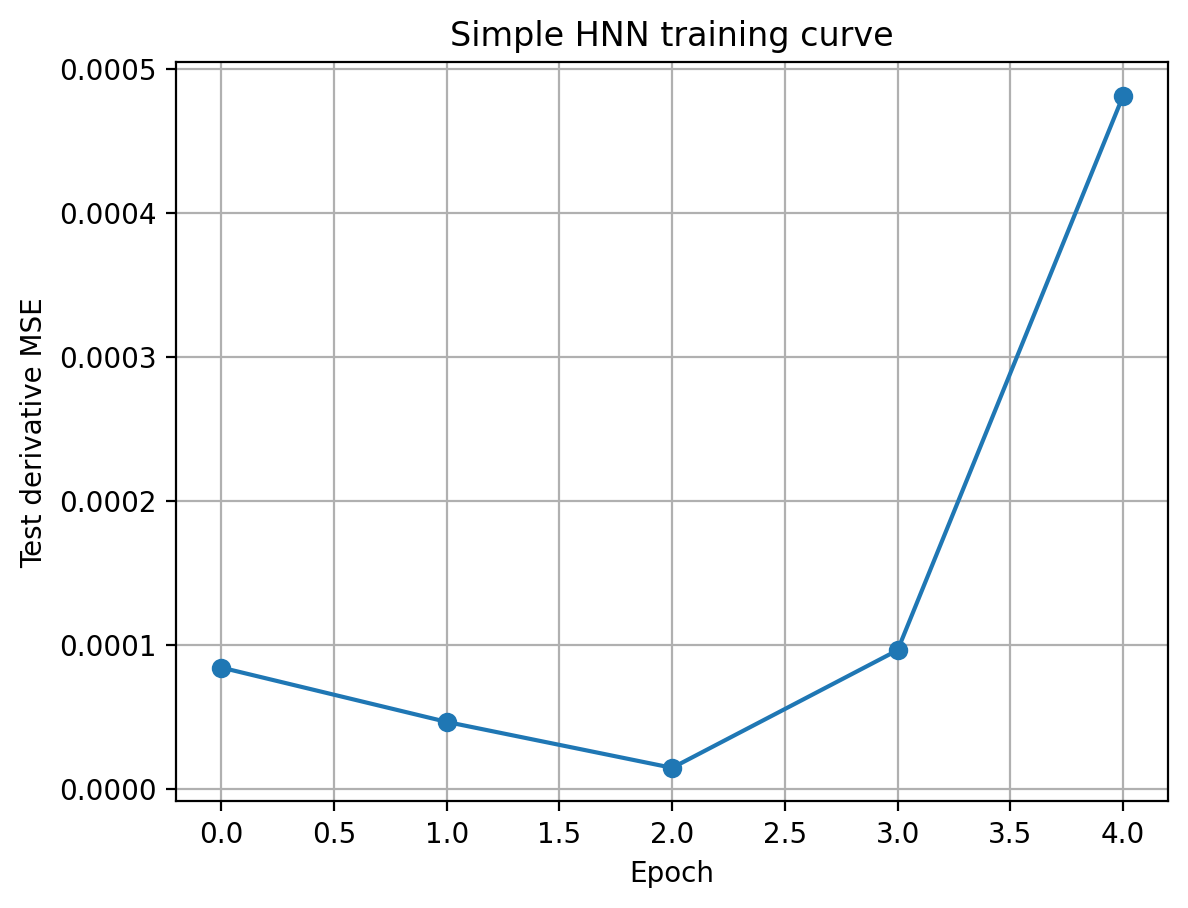

In [59]:

# --- Simple Hamiltonian Neural Network (HNN) training demo ---
import functools
#from flax import linen as fnn
import optax

class SimpleHNN(nn.Module):
    dim: int
    hidden: int = 128

    @nn.compact
    def __call__(self, coords):
        x = coords # (B, 2n)
        x = nn.tanh(nn.Dense(self.hidden)(x))
        x = nn.tanh(nn.Dense(self.hidden)(x))
        H = nn.Dense(1)(x)
        return H.squeeze(-1)

def hnn_time_derivative(params, model, coords):
    def total_energy(z):
        return model.apply(params, z).sum()
    grad_H = jax.grad(total_energy)(coords)
    n_dim = coords.shape[-1] // 2
    dqdt = grad_H[:, n_dim:]
    dpdt = -grad_H[:, :n_dim]
    return jnp.concatenate([dqdt, dpdt], axis=-1)

# Use the same training data but only current coordinates and their time-derivatives.
coords_test = test_dataset[0]
derivs_test = test_dataset[1]

hnn_model = SimpleHNN(dim=x0_train.shape[1])
rng = jax.random.PRNGKey(123)
params_hnn = hnn_model.init(rng, x0_train[:batch_size])
tx_hnn = optax.adam(learning_rate=1e-3)
opt_state_hnn = tx_hnn.init(params_hnn)

@functools.partial(jax.jit, static_argnums=0)
def train_step_hnn(model, params, opt_state, coords, derivs):
    def loss_fn(p):
        pred = hnn_time_derivative(p, model, coords)
        return jnp.mean((pred - derivs) ** 2)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, opt_state = tx_hnn.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

@functools.partial(jax.jit, static_argnums=0)
def eval_step_hnn(model, params, coords, derivs):
    pred = hnn_time_derivative(params, model, coords)
    return jnp.mean((pred - derivs) ** 2)

hnn_epochs = 5
hnn_losses = []
for ep in range(hnn_epochs):
    perm_key, rng = jax.random.split(rng)
    perm = jax.random.permutation(perm_key, x0_train.shape[0])
    x0_train = x0_train[perm]
    x0_dot_train = x0_dot_train[perm]
    num_batches = x0_train.shape[0] // batch_size
    for i in range(num_batches):
        batch_coords = x0_train[i*batch_size:(i+1)*batch_size]
        batch_derivs = x0_dot_train[i*batch_size:(i+1)*batch_size]
        params_hnn, opt_state_hnn, loss_val = train_step_hnn(
            hnn_model, params_hnn, opt_state_hnn, batch_coords, batch_derivs
        )
    test_loss = eval_step_hnn(hnn_model, params_hnn, coords_test, derivs_test)
    hnn_losses.append(float(test_loss))
    print(f"[HNN] Epoch {ep+1}/{hnn_epochs}  test MSE: {float(test_loss):.6e}")

plt.figure()
plt.plot(hnn_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Test derivative MSE')
plt.title('Simple HNN training curve')
plt.grid(True)
plt.show()

# quick rollout sanity check on a short horizon
q0_hnn = q_true[:1]
p0_hnn = p_true[:1]
coords = jnp.concatenate([q0_hnn, p0_hnn], axis=-1)
def step_hnn(carry, _):
    coords = carry
    derivs = hnn_time_derivative(params_hnn, hnn_model, coords)
    next_coords = coords + derivs * dt
    return next_coords, next_coords


In [60]:

_, coords_seq = jax.lax.scan(step_hnn, coords, None, length=200)
coords_seq = np.asarray(jnp.concatenate([coords[None,...], coords_seq], axis=0)) # (T, 1, 2n)
q_hnn_pred = np.squeeze(coords_seq[..., :n], axis=1)   # (T, n)
p_hnn_pred = np.squeeze(coords_seq[..., n:], axis=1)   # (T, n)

if q_hnn_pred.ndim == 1:
    q_hnn_pred = q_hnn_pred[:, None]
if p_hnn_pred.ndim == 1:
    p_hnn_pred = p_hnn_pred[:, None]



In [61]:
print(q_true[:1], p_true[:1])

[[0.3736453]] [[0.44857118]]


In [62]:
print(q_hnn_pred[0,0], p_hnn_pred[0,0])

0.3736453 0.44857118


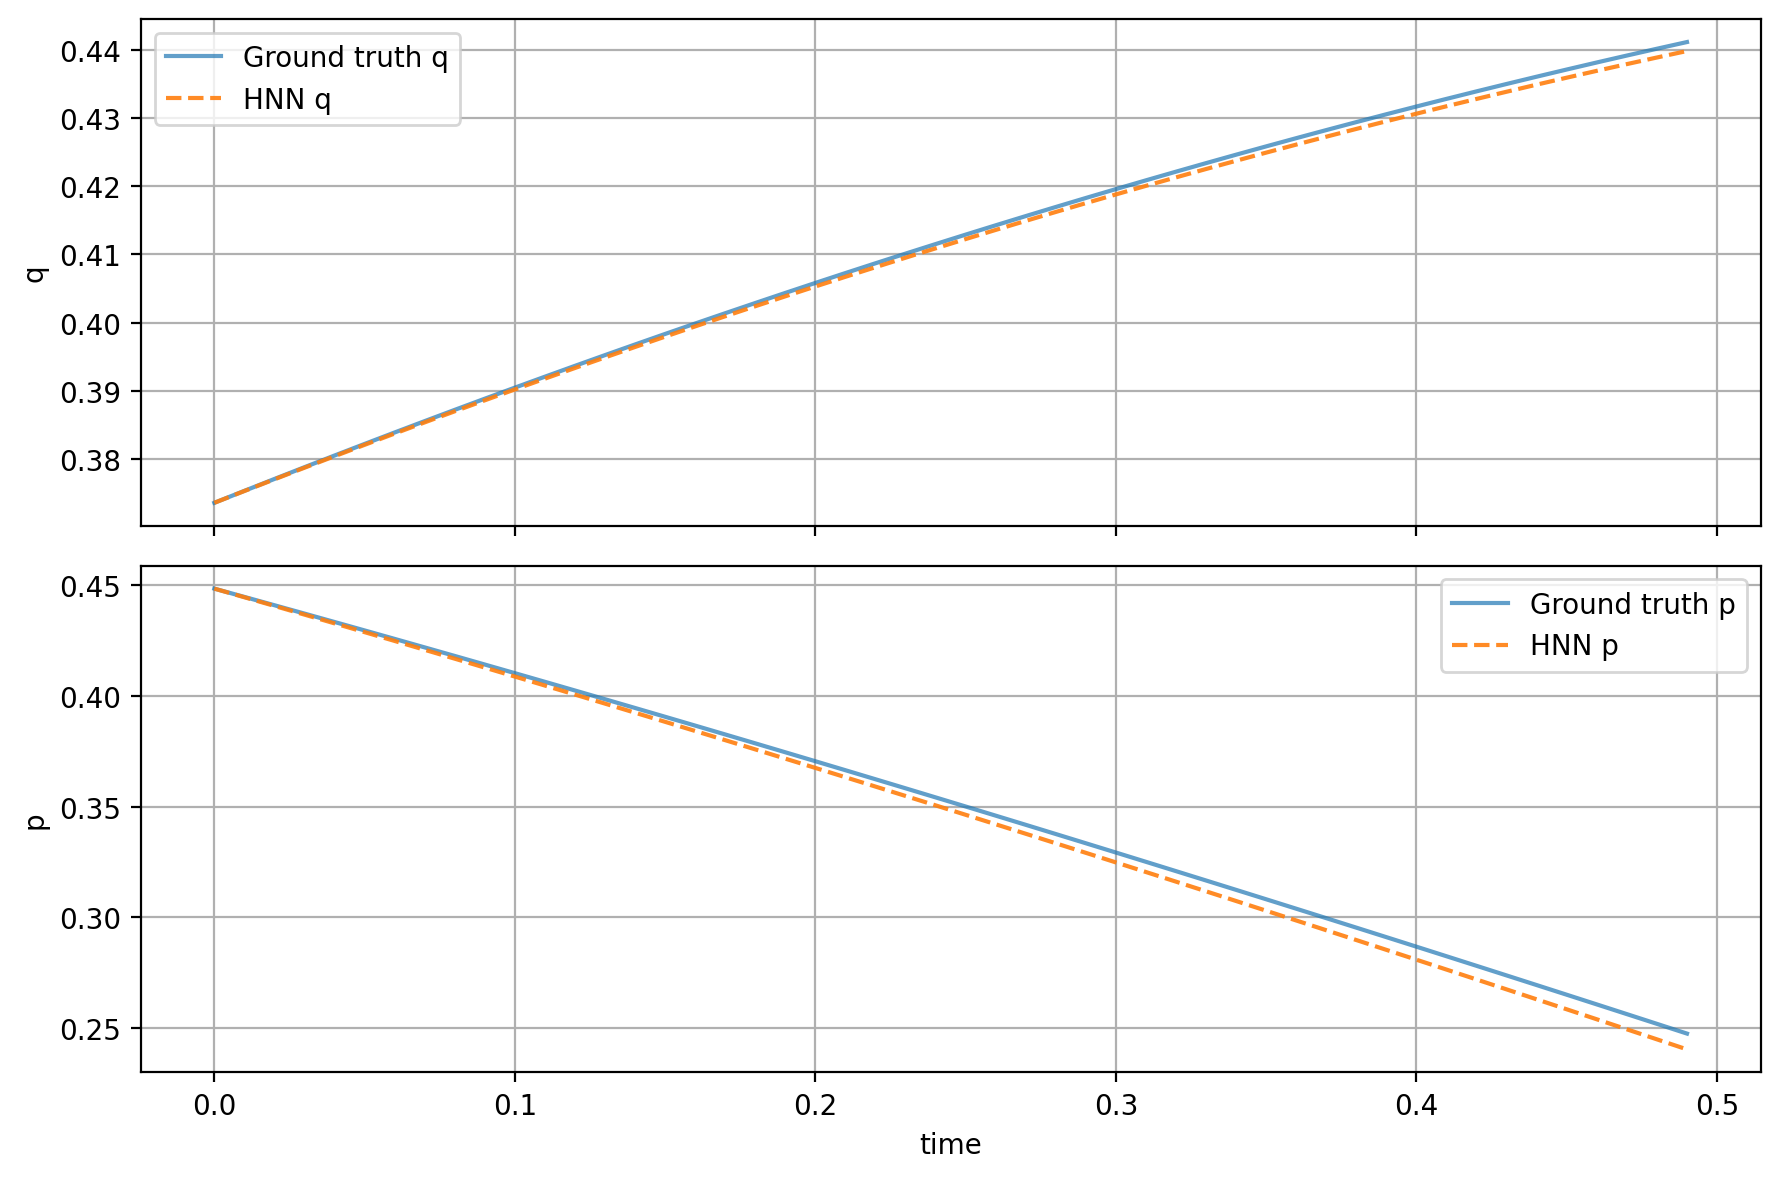

In [67]:

t_short = np.arange(coords_seq.shape[0]) * dt
q_true_arr = np.asarray(q_true)
p_true_arr = np.asarray(p_true)
min_len = min(t_short.shape[0], q_hnn_pred.shape[0], q_true_arr.shape[0], p_true_arr.shape[0])
t_short = t_short[:min_len]
q_pred_plot = q_hnn_pred[:min_len]
p_pred_plot = p_hnn_pred[:min_len]
q_gt_short = q_true_arr[:min_len]
p_gt_short = p_true_arr[:min_len]
if q_gt_short.ndim == 1:
    q_gt_short = q_gt_short[:, None]
if p_gt_short.ndim == 1:
    p_gt_short = p_gt_short[:, None]

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(t_short, q_gt_short[:, 0], label='Ground truth q', alpha=0.7)
axes[0].plot(t_short, q_pred_plot[:, 0], '--', label='HNN q', alpha=0.9)
axes[0].set_ylabel('q')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t_short, p_gt_short[:, 0], label='Ground truth p', alpha=0.7)
axes[1].plot(t_short, p_pred_plot[:, 0], '--', label='HNN p', alpha=0.9)
axes[1].set_ylabel('p')
axes[1].set_xlabel('time')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()



In [69]:
print(H_true_vals.shape, H_pred_vals.shape)

(256,) (256,)


In [70]:
t_vec

Array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49], dtype=float32)

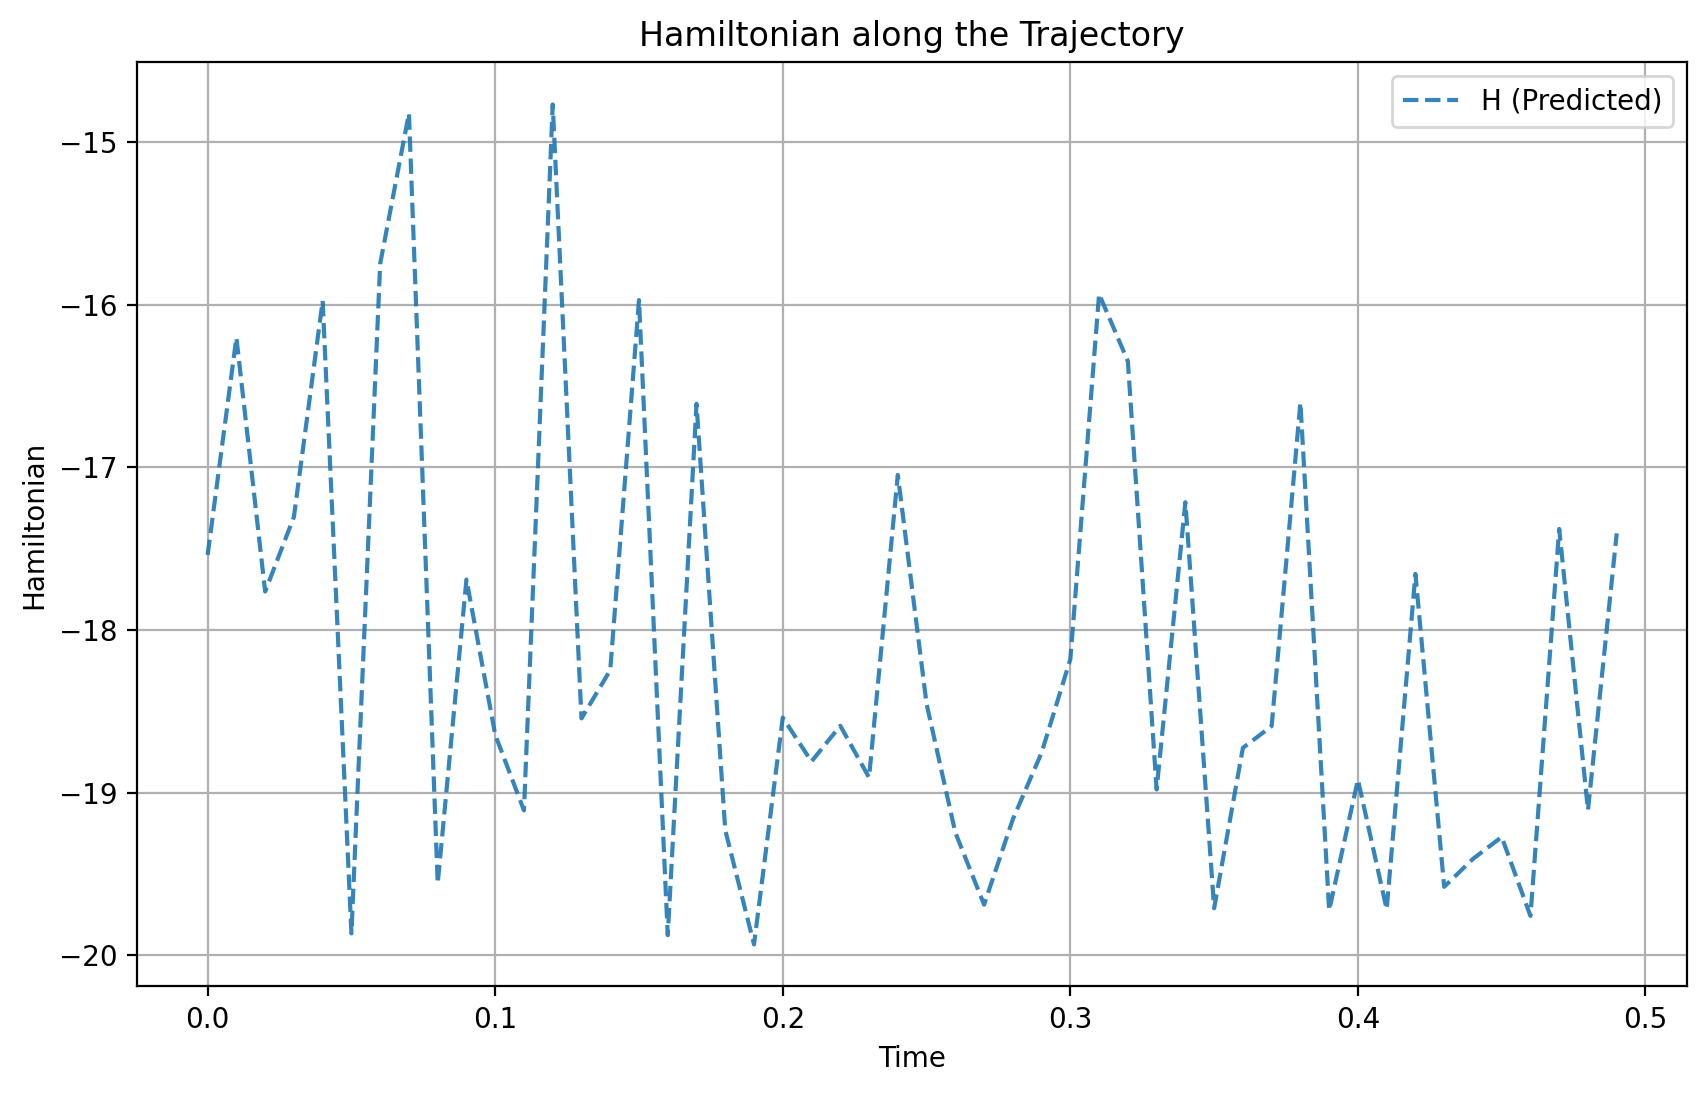

In [74]:
# --- Hamiltonian diagnostics ---
# Calculate true Hamiltonian along the trajectory
#H_true_vals = H_ground_truth(xt[:, :n], xt[:, n:], sim_params)

# Calculate predicted Hamiltonian along the trajectory
H_pred_vals = hnn_model.apply(params_hnn, jnp.concatenate([xt[:, :n], xt[:, n:]], axis=-1))

# Plot Hamiltonian values along the trajectory
plt.figure(figsize=(10, 6))
#plt.plot(t_vec[:min_len], H_true_vals[:min_len], label='H (Ground Truth)', alpha=0.7)
plt.plot(t_vec[:min_len], H_pred_vals[:min_len], '--', label='H (Predicted)', alpha=0.9)
plt.xlabel('Time')
plt.ylabel('Hamiltonian')
plt.title('Hamiltonian along the Trajectory')
plt.legend()
plt.grid(True)
plt.show()


In [45]:
q_gt_short.shape

(50, 1)

# AAN-style Hamiltonian Neural Network

In [27]:

# --- AAN-style Hamiltonian Neural Network ---
import functools
import optax

coords_train = x0_train
derivs_train = x0_dot_train
coords_test = test_dataset[0]
derivs_test = test_dataset[1]

aan_hnn_model = MyActionAngleNetwork(
    dim_config=n,
    dim_hidden_list=[64, 64, 64],
    num_gsblocks=20,
    type_polar="canonical",
    activation=nn.silu,
    mlp_res_connection=False,
    theta_predictor="gradient",
    learn_scale=True,
    #single_step_predictions=True,
)

rng = jax.random.PRNGKey(321)
params_aan_hnn = aan_hnn_model.init(
    rng,
    coords_train[:batch_size, :n],
    coords_train[:batch_size, n:],
    jnp.asarray(0.0),
    train=False,
)
tx_aan_hnn = optax.adam(learning_rate=1e-3)
opt_state_aan_hnn = tx_aan_hnn.init(params_aan_hnn)

def aan_hnn_time_derivative(params, model, q_in, p_in):
    def h_single(qi, pi):
        return model.apply(
            {'params': params},
            qi[None, :],
            pi[None, :],
            method=MyActionAngleNetwork.hamiltonian,
        ).squeeze()

    dHdq = jax.vmap(lambda qi, pi: jax.grad(h_single, argnums=0)(qi, pi))(q_in, p_in)
    dHdp = jax.vmap(lambda qi, pi: jax.grad(h_single, argnums=1)(qi, pi))(q_in, p_in)
    dqdt = dHdp
    dpdt = -dHdq
    return jnp.concatenate([dqdt, dpdt], axis=-1)

@functools.partial(jax.jit, static_argnums=0)
def train_step_aan_hnn(model, params, opt_state, coords, derivs):
    q_batch = coords[:, :n]
    p_batch = coords[:, n:]

    def loss_fn(p_):
        pred = aan_hnn_time_derivative(p_, model, q_batch, p_batch)
        return jnp.mean((pred - derivs) ** 2)

    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, opt_state = tx_aan_hnn.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

@functools.partial(jax.jit, static_argnums=0)
def eval_step_aan_hnn(model, params, coords, derivs):
    q_batch = coords[:, :n]
    p_batch = coords[:, n:]
    pred = aan_hnn_time_derivative(params, model, q_batch, p_batch)
    return jnp.mean((pred - derivs) ** 2)

aan_hnn_epochs = 5
aan_hnn_losses = []
coords_train_local = coords_train
derivs_train_local = derivs_train

for ep in range(aan_hnn_epochs):
    perm_key, rng = jax.random.split(rng)
    perm = jax.random.permutation(perm_key, coords_train_local.shape[0])
    coords_train_local = coords_train_local[perm]
    derivs_train_local = derivs_train_local[perm]
    num_batches = coords_train_local.shape[0] // batch_size
    for i in range(num_batches):
        batch_coords = coords_train_local[i * batch_size:(i + 1) * batch_size]
        batch_derivs = derivs_train_local[i * batch_size:(i + 1) * batch_size]
        params_aan_hnn, opt_state_aan_hnn, _ = train_step_aan_hnn(
            aan_hnn_model,
            params_aan_hnn,
            opt_state_aan_hnn,
            batch_coords,
            batch_derivs,
        )
    test_loss = eval_step_aan_hnn(aan_hnn_model, params_aan_hhn, coords_test, derivs_test)
    aan_hnn_losses.append(float(test_loss))
    print(f"[AAN-HNN] Epoch {ep+1}/{aan_hnn_epochs}  test MSE: {float(test_loss):.6e}")

plt.figure()
plt.plot(aan_hnn_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Test derivative MSE')
plt.title('AAN-style HNN training curve')
plt.grid(True)
plt.show()

q0_start = q_true[:1]
p0_start = p_true[:1]
coords0 = jnp.concatenate([q0_start, p0_start], axis=-1)

def step_aan_hnn(carry, _):
    coords = carry
    q_curr = coords[:, :n]
    p_curr = coords[:, n:]
    derivs = aan_hnn_time_derivative(params_aan_hnn, aan_hnn_model, q_curr, p_curr)
    next_coords = coords + derivs * dt
    return next_coords, next_coords

_, coords_scan = jax.lax.scan(step_aan_hnn, coords0, None, length=200)
coords_scan = np.asarray(coords_scan)
q_aan_hnn = np.squeeze(coords_scan[..., :n], axis=1)
p_aan_hnn = np.squeeze(coords_scan[..., n:], axis=1)
if q_aan_hnn.ndim == 1:
    q_aan_hnn = q_aan_hnn[:, None]
if p_aan_hnn.ndim == 1:
    p_aan_hnn = p_aan_hnn[:, None]




2025-11-05 07:35:19.770230: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-11-05 07:35:20.544631: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


ValueError: Non-hashable static arguments are not supported. An error occurred while trying to hash an object of type <class 'action_angle_networks.sk_models.MyActionAngleNetwork'>, MyActionAngleNetwork(
    # attributes
    dim_config = 1
    dim_hidden = 64
    num_gsblocks = 20
    type_polar = 'canonical'
    activation = silu
    mlp_res_connection = False
    theta_predictor = 'gradient'
    dim_hidden_list = [64, 64, 64]
    learn_scale = True
). The error was:
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/ipykernel_launcher.py", line 18, in <module>
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 1075, in launch_instance
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 739, in start
  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 205, in

In [ ]:

t_scan = np.arange(q_aan_hnn.shape[0]) * dt
q_true_arr = np.asarray(q_true)
p_true_arr = np.asarray(p_true)
min_len = min(t_scan.shape[0], q_true_arr.shape[0], p_true_arr.shape[0])
t_scan = t_scan[:min_len]
q_pred_plot = q_aan_hnn[:min_len]
p_pred_plot = p_aan_hnn[:min_len]
q_gt_plot = q_true_arr[:min_len]
p_gt_plot = p_true_arr[:min_len]
if q_gt_plot.ndim == 1:
    q_gt_plot = q_gt_plot[:, None]
if p_gt_plot.ndim == 1:
    p_gt_plot = p_gt_plot[:, None]

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(t_scan, q_gt_plot[:, 0], label='Ground truth q', alpha=0.7)
axes[0].plot(t_scan, q_pred_plot[:, 0], '--', label='AAN-style HNN q', alpha=0.9)
axes[0].set_ylabel('q')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t_scan, p_gt_plot[:, 0], label='Ground truth p', alpha=0.7)
axes[1].plot(t_scan, p_pred_plot[:, 0], '--', label='AAN-style HNN p', alpha=0.9)
axes[1].set_ylabel('p')
axes[1].set_xlabel('time')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()



In [31]:

# --- Inline AAN-style Hamiltonian Neural Network (with explicit layers) ---
import functools
import optax

from action_angle_networks.sk_layers import (
    GSBlock,
    GSympNet,
    GotosCanonicalPolarCoordinates,
    InverseGotosCanonicalPolarCoordinates,
    MLPFlexible,
)

class InlineAANHamiltonian(nn.Module):
    dim_config: int
    dim_hidden: int = 64
    num_gsblocks: int = 20
    activation: Callable = nn.relu
    dim_hidden_list: Optional[List[int]] = None
    # dim_hidden_list: Sequence[int] = (64, 64, 64)
    learn_scale: bool = True

    def setup(self):
        self.gsymp_net = GSympNet(self.dim_config, self.dim_hidden, self.num_gsblocks, self.activation)
        self.to_polar = GotosCanonicalPolarCoordinates(self.dim_config)
        self.inv_polar = InverseGotosCanonicalPolarCoordinates(self.dim_config)
        dim_hidden_list = [self.dim_hidden, self.dim_hidden] if self.dim_hidden_list is None else self.dim_hidden_list
        self.H_of_I = MLPFlexible(
                #dim_input=self.dim_config,
                dim_output=1, # output scalar Hamiltonian
                dim_hidden_list=dim_hidden_list,
                activation=self.activation,
            )
        # self.H_of_I = MLPFlexible(self.dim_config, list(self.dim_hidden_list), 1, self.activation)
        if self.learn_scale:
            self.scale_q = self.param('scale_q', nn.initializers.ones, (self.dim_config,))
            self.scale_p = self.param('scale_p', nn.initializers.ones, (self.dim_config,))
        else:
            self.scale_q = 1.0
            self.scale_p = 1.0

    def __call__(self, q, p):
        q_scale = self.scale_q / jnp.sqrt(self.scale_q * self.scale_p)
        p_scale = self.scale_p / jnp.sqrt(self.scale_q * self.scale_p)
        q_s = q * q_scale[None, ...]
        p_s = p * p_scale[None, ...]
        Ix, Iy = self.gsymp_net(q_s, p_s)
        I, _ = self.to_polar(Ix, Iy)
        H = self.H_of_I(I).squeeze(-1)
        return H

def inline_time_derivative(params, model, q_in, p_in):
    def H_single(qi, pi):
        return model.apply(params, qi[None, :], pi[None, :]).squeeze()
    dHdq = jax.vmap(lambda qi, pi: jax.grad(H_single, argnums=0)(qi, pi))(q_in, p_in)
    dHdp = jax.vmap(lambda qi, pi: jax.grad(H_single, argnums=1)(qi, pi))(q_in, p_in)
    dqdt = dHdp
    dpdt = -dHdq
    return jnp.concatenate([dqdt, dpdt], axis=-1)


In [32]:

inline_model = InlineAANHamiltonian(dim_config=n)
rng = jax.random.PRNGKey(4321)
params_inline = inline_model.init(rng, coords_train[:batch_size, :n], coords_train[:batch_size, n:])
tx_inline = optax.adam(learning_rate=1e-3)
opt_state_inline = tx_inline.init(params_inline)

@functools.partial(jax.jit, static_argnums=0)
def train_step_inline(model, params, opt_state, coords, derivs):
    q_batch = coords[:, :n]
    p_batch = coords[:, n:]
    def loss_fn(p_):
        pred = inline_time_derivative(p_, model, q_batch, p_batch)
        return jnp.mean((pred - derivs) ** 2)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, opt_state = tx_inline.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

@functools.partial(jax.jit, static_argnums=0)
def eval_step_inline(model, params, coords, derivs):
    q_batch = coords[:, :n]
    p_batch = coords[:, n:]
    pred = inline_time_derivative(params, model, q_batch, p_batch)
    return jnp.mean((pred - derivs) ** 2)

inline_epochs = 5
inline_losses = []
coords_train_local = coords_train
derivs_train_local = derivs_train

for ep in range(inline_epochs):
    perm_key, rng = jax.random.split(rng)
    perm = jax.random.permutation(perm_key, coords_train_local.shape[0])
    coords_train_local = coords_train_local[perm]
    derivs_train_local = derivs_train_local[perm]
    num_batches = coords_train_local.shape[0] // batch_size
    for i in range(num_batches):
        batch_coords = coords_train_local[i * batch_size:(i + 1) * batch_size]
        batch_derivs = derivs_train_local[i * batch_size:(i + 1) * batch_size]
        params_inline, opt_state_inline, _ = train_step_inline(
            inline_model, params_inline, opt_state_inline,
            batch_coords, batch_derivs,
        )
    test_loss = eval_step_inline(inline_model, params_inline, coords_test, derivs_test)
    inline_losses.append(float(test_loss))
    print(f"[Inline AAN-HNN] Epoch {ep+1}/{inline_epochs}  test MSE: {float(test_loss):.6e}")

plt.figure()
plt.plot(inline_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Test derivative MSE')
plt.title('Inline AAN-style HNN training curve')
plt.grid(True)
plt.show()

coords0 = jnp.concatenate([q_true[:1], p_true[:1]], axis=-1)
def step_inline(carry, _):
    q_curr = carry[:, :n]
    p_curr = carry[:, n:]
    derivs = inline_time_derivative(params_inline, inline_model, q_curr, p_curr)
    next_coords = carry + derivs * dt
    return next_coords, next_coords

_, coords_inline = jax.lax.scan(step_inline, coords0, None, length=200)
coords_inline = np.asarray(coords_inline)
q_inline = np.squeeze(coords_inline[..., :n], axis=1)
p_inline = np.squeeze(coords_inline[..., n:], axis=1)
if q_inline.ndim == 1:
    q_inline = q_inline[:, None]
if p_inline.ndim == 1:
    p_inline = p_inline[:, None]

t_inline = np.arange(q_inline.shape[0]) * dt
q_gt_inline = np.asarray(q_true)
p_gt_inline = np.asarray(p_true)
min_len = min(t_inline.shape[0], q_gt_inline.shape[0])
t_inline = t_inline[:min_len]
q_inline = q_inline[:min_len]
p_inline = p_inline[:min_len]
q_gt_inline = q_gt_inline[:min_len]
p_gt_inline = p_gt_inline[:min_len]
if q_gt_inline.ndim == 1:
    q_gt_inline = q_gt_inline[:, None]
if p_gt_inline.ndim == 1:
    p_gt_inline = p_gt_inline[:, None]

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(t_inline, q_gt_inline[:, 0], label='Ground truth q', alpha=0.7)
axes[0].plot(t_inline, q_inline[:, 0], '--', label='Inline AAN-HNN q', alpha=0.9)
axes[0].set_ylabel('q')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t_inline, p_gt_inline[:, 0], label='Ground truth p', alpha=0.7)
axes[1].plot(t_inline, p_inline[:, 0], '--', label='Inline AAN-HNN p', alpha=0.9)
axes[1].set_ylabel('p')
axes[1].set_xlabel('time')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()



TypeError: The input arguments to the custom_jvp-decorated function relu could not be resolved to positional-only arguments. Binding failed with the error:
missing a required argument: 'x'